## **Imports des librairies**

In [1]:
from typing import (
    Any,
    List,
    Tuple,
    Mapping,
    Sequence)
from collections.abc import Iterator
from pathlib import Path
from os import environ
from pprint import pprint

import joblib
import math
import random

from sklearn.base import (
    TransformerMixin,
    ClassifierMixin)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder,
    PowerTransformer)
from sklearn.compose import (
    ColumnTransformer,
    make_column_transformer)
from sklearn.pipeline import (
    Pipeline,
    make_pipeline)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate)
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay)
from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay)
from sklearn.linear_model import LogisticRegression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## **Sélection d'une seed fixe**

In [2]:
rand_seed: int = 42

random.seed(rand_seed)

## **Chargement du dataset**

In [3]:
df_file: str = r"..\\..\Dataset\Student Depression Dataset\Dataset.csv"

df_ori: pd.DataFrame = pd.read_csv(filepath_or_buffer = df_file)

# **Analyse exploratoire des données**

### **Vue d'ensemble du dataset**

In [4]:
df_ori.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.000000,12500.00000,12500.000000,12499.000000,12500.000000
mean,31536.908720,25.810880,3.131440,0.000400,7.666749,2.931920,0.00056,7.173040,3.140971,0.586000
std,18214.972469,4.900032,1.384282,0.044721,1.466057,1.361262,0.04472,3.692396,1.448525,0.492568
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,15798.500000,21.000000,2.000000,0.000000,6.290000,2.000000,0.00000,4.000000,2.000000,0.000000
50%,31310.500000,25.000000,3.000000,0.000000,7.770000,3.000000,0.00000,8.000000,3.000000,1.000000
75%,47256.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.00000,10.000000,4.000000,1.000000
max,63219.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.00000,12.000000,5.000000,1.000000


In [5]:
df_ori.info()

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     12500 non-null  int64  
 1   Gender                                 12500 non-null  str    
 2   Age                                    12500 non-null  int64  
 3   City                                   12500 non-null  str    
 4   Profession                             12500 non-null  str    
 5   Academic Pressure                      12500 non-null  int64  
 6   Work Pressure                          12500 non-null  int64  
 7   CGPA                                   12500 non-null  float64
 8   Study Satisfaction                     12500 non-null  int64  
 9   Job Satisfaction                       12500 non-null  int64  
 10  Sleep Duration                         12500 non-null  str    
 11  Dietary Habit

In [6]:
display("Nombre de valeurs nulles")
display(df_ori.isna().sum())
print("\n" * 2)

display("Nombre de doublons purs")
display(df_ori.duplicated().sum())
print("\n" * 2)

'Nombre de valeurs nulles'

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         1
Family History of Mental Illness         0
Depression                               0
dtype: int64

'Nombre de doublons purs'

np.int64(0)

In [7]:
series_target_val_count: pd.Series = df_ori["Depression"].value_counts()
target_val_count_false: int = series_target_val_count[0]
target_val_count_true: int = series_target_val_count[1]
ratio_target_false_true: float = target_val_count_false / target_val_count_true

print("target_false_count\n\t", target_val_count_false)
print("target_true_count\n\t", target_val_count_true)
print("ratio_target_false_true\n\t", ratio_target_false_true)

target_false_count
	 5175
target_true_count
	 7325
ratio_target_false_true
	 0.7064846416382252


# **Transformation des données**

Ajout de colonnes pour la suite des opérations

In [8]:
df : pd.DataFrame = pd.DataFrame(columns = list(df_ori.columns) + ["professionPressure", "professionSatisfaction"])

## **Suppression des lignes dont la "profession" n'est pas "Student"**

In [9]:
count : int = 0
# for row_idx in range(len(df_ori[0:100])):
for row_idx in range(len(df_ori)):
    row_data : pd.Series = df_ori.iloc[row_idx]
    
    if (row_data["Profession"] == "Student"):
        df = pd.concat([df, pd.DataFrame([row_data])],
                       ignore_index = True)
        # count += 1
        # if (count >= 5):
        #     break

display(df)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,professionPressure,professionSatisfaction
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1,NaN,NaN
1,8,Female,24,Bangalore,Student,2,0,5.9,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0,NaN,NaN
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0,NaN,NaN
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1,NaN,NaN
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12482,63192,Male,26,Faridabad,Student,4,0,7.77,1,0,7-8 hours,Healthy,BA,Yes,10,5.0,No,0,NaN,NaN
12483,63198,Male,33,Srinagar,Student,4,0,8.55,5,0,More than 8 hours,Unhealthy,MSc,Yes,10,5.0,No,0,NaN,NaN
12484,63215,Male,33,Pune,Student,1,0,9.84,1,0,Less than 5 hours,Moderate,MBA,Yes,5,1.0,Yes,0,NaN,NaN
12485,63218,Male,32,Vadodara,Student,3,0,8.54,4,0,5-6 hours,Healthy,M.Tech,Yes,11,3.0,Yes,1,NaN,NaN


## **Modification des colonnes**

### **Fusion de colonnes aux sémantiques semblables**

In [10]:
# for row_idx in range(len(df)):
#     df_row : pd.Series = df.iloc[row_idx]

#     # Fusion des colonnes 'Academic Pressure' et 'Work Pressure' (afin de créer une colonne "générique" exprimant une idée semblable)
#     key_ori_pressure : str = ""
#     if (df_row["Profession"] == "Student"):
#         key_ori_pressure = df["Academic Pressure"]
#     else:
#         key_ori_pressure = df["Work Pressure"]

#     # Fusion des colonnes 'Study Satisfaction' et 'Job Satisfaction' (afin de créer une colonne "générique" exprimant une idée semblable)
#     key_ori_satisfaction : str = ""
#     if (df_row["Profession"] == "Student"):
#         key_ori_satisfaction = df["Study Satisfaction"]
#     else:
#         key_ori_satisfaction = df["Job Satisfaction"]

#     df.iloc[row_idx] = df_row



for row_idx in range(len(df)):
    df_row : pd.Series = df.iloc[row_idx]

    # Fusion des colonnes 'Academic Pressure' et 'Work Pressure' (afin de créer une colonne "générique" exprimant une idée semblable)*
    if (df_row["Profession"] == "Student"):
        df_row["professionPressure"] = df_row["Academic Pressure"]
    else:
        df_row["professionPressure"] = df_row["Work Pressure"]

    # Fusion des colonnes 'Study Satisfaction' et 'Job Satisfaction' (afin de créer une colonne "générique" exprimant une idée semblable)
    if (df_row["Profession"] == "Student"):
        df_row["professionSatisfaction"] = df_row["Study Satisfaction"]
    else:
        df_row["professionSatisfaction"] = df_row["Job Satisfaction"]

    df.iloc[row_idx] = df_row


df = df.drop(["id", "Academic Pressure", "Work Pressure", "Study Satisfaction", "Job Satisfaction"],
            axis = "columns")

### **Changements des noms et réorganisation des colonnes**

In [11]:
map_column_name : dict = {
    "Gender" : "gender",
    "Age" : "age",
    "City" : "city",
    "Profession" : "profession",
    "CGPA" : "cgpa",
    "Sleep Duration" : "sleep_duration",
    "Dietary Habits" : "dietary_habits",
    "Degree" : "degree",
    "Have you ever had suicidal thoughts ?" : "history_thoughts_suicidal",
    "Work/Study Hours" : "profession_hour_daily",
    "Financial Stress" : "financial_stress",
    "Family History of Mental Illness" : "history_family_illness_mental",
    "Depression" : "depression",
    "professionPressure" : "profession_pressure",
    "professionSatisfaction" : "profession_satisfaction"
}

df = df.rename(columns = map_column_name)

df = df.iloc[:, [0, 1, 2, 4, 7, 3, 9, 13, 14, 10, 5, 6, 11, 8, 12]]

## **Répartition des features en types de données**

In [12]:
col_type_bool: list[str] = ["history_family_illness_mental", "history_thoughts_suicidal", "depression"]
col_type_label: list[str] = ["gender", "degree", "profession", "sleep_duration", "dietary_habits"]
col_type_string: list[str] = ["city"]
col_type_float: list[str] = ["cgpa"]
col_type_int: list[str] = ["age", "profession_hour_daily", "profession_pressure", "profession_satisfaction", "financial_stress"]

col_categorical: list[str] = col_type_bool + col_type_label + col_type_string
col_numerical: list[str] = col_type_float + col_type_int

_ALL = col_type_string + col_type_int + col_type_float + col_type_bool + col_type_label

for col in df.columns:
    if (col not in _ALL):
        print(f"{col} not in _ALL")

## **Observations des valeurs des features catégorielles**

In [13]:
# display(df[col_categorical].value_counts())

for col in col_categorical:
    display(df[col].value_counts())

history_family_illness_mental
No     6459
Yes    6028
Name: count, dtype: int64

history_thoughts_suicidal
Yes    7863
No     4624
Name: count, dtype: int64

depression
1    7312
0    5175
Name: count, dtype: int64

gender
Male      6994
Female    5493
Name: count, dtype: int64

degree
Class 12    2718
B.Ed         821
B.Com        694
B.Arch       638
BCA          615
B.Tech       534
MSc          515
M.Tech       474
MCA          471
BHM          427
BSc          412
B.Pharm      371
M.Ed         348
M.Com        341
BBA          311
LLB          307
MBBS         299
BE           267
BA           266
MBA          256
MD           253
M.Pharm      250
MA           249
PhD          236
LLM          221
MHM           90
ME            84
Others        19
Name: count, dtype: int64

profession
Student    12487
Name: count, dtype: int64

sleep_duration
Less than 5 hours    3759
7-8 hours            3318
5-6 hours            2705
More than 8 hours    2696
Others                  9
Name: count, dtype: int64

dietary_habits
Unhealthy    4663
Moderate     4415
Healthy      3404
Others          5
Name: count, dtype: int64

city
Kalyan                708
Vasai-Virar           628
Srinagar              617
Hyderabad             583
Ludhiana              540
Thane                 518
Agra                  505
Lucknow               497
Jaipur                474
Kolkata               462
Patna                 454
Surat                 451
Visakhapatnam         418
Pune                  415
Bhopal                406
Chennai               399
Ahmedabad             395
Rajkot                355
Bangalore             353
Delhi                 352
Vadodara              345
Mumbai                343
Meerut                341
Ghaziabad             327
Varanasi              319
Indore                279
Nagpur                275
Kanpur                268
Nashik                251
Faridabad             200
Saanvi                  1
M.Tech                  1
Bhavna                  1
Less Delhi              1
City                    1
3                       1
Less than 5 Kalyan      1
Mira                    1
Harsha 

## **Séparation des variables explicatives (features) de la variable expliquée (target)**

In [14]:
df = df.dropna(
    axis = 0,
    subset = "depression"
)

series_depression: pd.Series = df["depression"]

df_X: pd.DataFrame = df.drop(
    axis = 1,
    labels = ["depression"]
)
df_Y: pd.DataFrame = pd.DataFrame(df["depression"])

## **Type casting (pour s'assurer que les données soient dans le bon type/format)**

In [15]:
##### Type casting

### BOOL
# Essaie de cast "val" en "bool"
def val_ensure_bool(val: str|int) -> bool:
    returned: bool
    try:
        mapping: dict[str|int, bool] = {
            "NO": False, "No": False, "no": False, "0": False, 0: False,
            "YES": True, "Yes": True, "yes": True, "1": True, 1: True
        }
        returned = mapping[val]
        
    except:
        print("A value couldn't be casted into 'bool'")
        returned = False
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "bool"
def df_ensure_bool(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[bool] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_bool(series.loc[index]))

    # display(pd.Series(data=series_return, name=col).head())

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### LABEL --- WIP: A modifier pour s'assurer que la valeur se trouve dans une liste prédéfinie
# Essaie de cast "val" en "label"
def val_ensure_label(val: Any, list_label: list[str]) -> str:
    returned: str
    try:
        returned = str(val) if str(val) in list_label else ""
        
    except:
        print("A value couldn't be casted into 'label'")
        returned = ""
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "label"
def df_ensure_label(series: pd.Series, list_label) -> pd.Series:
    col: str = str(series.name)

    series_return: list[str] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_label(series.loc[index], list_label))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### STRING
# Essaie de cast "val" en "str"
def val_ensure_str(val: Any) -> str:
    returned: str
    try:
        returned = str(val)
        
    except:
        print("A value couldn't be casted into 'str'")
        returned = ""
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "str"
def df_ensure_str(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[str] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_str(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### FLOAT
# Essaie de cast "val" en "float"
def val_ensure_float(val: Any) -> float:
    returned: float
    try:
        returned = float(val)
    # except ValueError as e:
    
    except:
        print("A value couldn't be casted into 'float'")
        returned = np.nan
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "float"
def df_ensure_float(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[float] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_float(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### INT
# Essaie de cast "val" en "int"
def val_ensure_int(val: Any) -> int:
    returned: int
    try:
        returned = int(float(val))
    except:
        print("A value couldn't be casted into 'int'")
        returned = 0
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "int"
def df_ensure_int(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[int] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_int(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)


In [16]:
dict_list_label: dict[str, list[str]] = {
    "gender" : [
        "Female", "Male", "Other" ],
    "degree" : [
        "B.Arch", "B.Com", "B.Ed", "B.Pharm", "B.Tech", "BA", "BBA", "BCA", "BE", "BHM", "BSc", "Class 12", "LLB", "LLM", "M.Com", "M.Ed", "M.Pharm", "M.Tech", "MA", "MBA", "MBBS", "MCA", "MD", "ME", "MHM", "MSc", "Others", "PhD" ],
    "profession" : [
        "Architect", "Chef", "Civil Engineer", "Content Writer", "Digital Marketer", "Doctor", "Educational Consultant", "Entrepreneur", "Lawyer", "Manager", "Pharmacist", "Student", "Teacher", "UX/UI Designer" ],
    "sleep_duration" : [
        "Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours", "Others" ],
    "dietary_habits" : [
        "Healthy", "Moderate", "Unhealthy", "Others" ]
}

In [17]:
for column in df_X.columns:
    df_part: pd.Series = df_X[column]

    
    if (column in col_type_bool):
        df_part = df_ensure_bool(df_part)
    elif (column in col_type_label):
        df_part = df_ensure_label(df_part, list_label = dict_list_label[column])
    elif (column in col_type_string):
        df_part = df_ensure_str(df_part)
    elif (column in col_type_int):
        df_part = df_ensure_int(df_part)
    elif (column in col_type_float):
        df_part = df_ensure_float(df_part)
    else:
        df_part = df_part

    df_X[column] = df_part


df_Y = pd.DataFrame(df_ensure_bool(df_Y.iloc[:, 0]))

# display(df_X[487:490])
# display(df_Y[487:490])

A value couldn't be casted into 'int'


In [18]:
display("df_X")
df_X.info()
display("df_Y")
df_Y.info()

'df_X'

<class 'pandas.DataFrame'>
RangeIndex: 12487 entries, 0 to 12486
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         12487 non-null  str    
 1   age                            12487 non-null  int64  
 2   city                           12487 non-null  str    
 3   cgpa                           12487 non-null  float64
 4   degree                         12487 non-null  str    
 5   profession                     12487 non-null  str    
 6   profession_hour_daily          12487 non-null  int64  
 7   profession_pressure            12487 non-null  int64  
 8   profession_satisfaction        12487 non-null  int64  
 9   financial_stress               12487 non-null  int64  
 10  sleep_duration                 12487 non-null  str    
 11  dietary_habits                 12487 non-null  str    
 12  history_family_illness_mental  12487 non-null  bool   
 1

'df_Y'

<class 'pandas.DataFrame'>
RangeIndex: 12487 entries, 0 to 12486
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   depression  12487 non-null  bool 
dtypes: bool(1)
memory usage: 12.3 KB


## **Détection des outliers**

In [19]:
# series: pd.Series = pd.Series([0, 1, 2])
series: pd.Series = pd.Series([0, 1])
series_mean = 0
series_std = 0

if (len(series) > 0):
    if (series_mean == 0.0):
        series_mean = series.mean()
    if (series_std == 0.0):
        series_std = series.std() if (series.std() > 0) else (10**(-10))
        # series_std = series.std() or (10**(-10))

print("series_mean\n\t", series_mean)
print("series_std\n\t", series_std)

series_mean
	 0.5
series_std
	 0.7071067811865476


In [20]:
def compute_zscore(datapoint_value: float, series_mean: float = 0.0, series_std: float = 0.0, series: pd.Series = pd.Series([])) -> float:
    if (len(series) > 0):
        if (series_mean == 0.0):
            series_mean = series.mean()
        if (series_std == 0.0):
            std = series.std()
            series_std = std if (std > 0) else (10**(-10))

    zscore: float = (datapoint_value - series_mean) / series_std

    return zscore



def is_outlier(datapoint_value: float, series_mean: float = 0.0, series_std: float = 0.0, series: pd.Series = pd.Series([])) -> bool:
    zscore: float = compute_zscore(
        datapoint_value = datapoint_value,
        series_mean = series_mean,
        series_std = series_std,
        series = series)
    
    outlier_threshold: float = 3.0
    outlier_test: bool = False
    if (abs(zscore) > outlier_threshold):
        outlier_test = True

    return outlier_test



def series_compute_mean_std(series: pd.Series) -> dict[str, float]:
    computed: dict[str, float] = {
        "mean": series.mean(),
        "std": series.std()}
    
    return computed



print(f"Nombre entrées AVANT suppression des outliers :\n\t{len(df_X)}")

count_outlier: int = 0
for col in [*col_type_int, *col_type_float]:
    col_mean_std: dict[str, float] = series_compute_mean_std(series = df_X[col])
    col_mean: float = col_mean_std["mean"]
    col_std: float = col_mean_std["std"]

    list_outlier_idx: list[int] = []
    for (datapoint_idx, datapoint_value) in enumerate(df_X[col]):
        outlier_test: bool = is_outlier(
            datapoint_value = datapoint_value,
            series_mean = col_mean,
            series_std = col_std)
        
        if (outlier_test):
            # print(compute_zscore(datapoint_value=datapoint_value, series=df_X[col]))
            list_outlier_idx.append(datapoint_idx)
            count_outlier += 1

    if (list_outlier_idx):
        display("Outlier(s) dans " + col)
        display(df_X.iloc[list_outlier_idx])

        # Suppression des outliers
        df_X = df_X.drop(
            labels = list_outlier_idx,
            axis = "index" ).reset_index(drop=True)
        df_Y = df_Y.drop(
            labels = list_outlier_idx,
            axis = "index" ).reset_index(drop=True)

print(f"(Nombre d'outliers : {count_outlier})")
print(f"Nombre entrées APRES suppression des outliers :\n\t{len(df_X)}")

Nombre entrées AVANT suppression des outliers :
	12487


'Outlier(s) dans age'

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
1074,Female,42,Rajkot,9.03,Class 12,Student,3,2,5,1,More than 8 hours,Moderate,True,True
2904,Female,58,Chennai,8.58,Class 12,Student,4,4,1,4,7-8 hours,Healthy,False,False
3429,Male,49,Nagpur,6.47,Class 12,Student,2,3,3,1,5-6 hours,Moderate,True,True
4377,Female,51,Bhopal,8.26,MBBS,Student,5,2,3,5,Less than 5 hours,Moderate,True,True
5527,Female,44,Srinagar,6.83,BSc,Student,4,1,3,3,Less than 5 hours,Unhealthy,False,False
6652,Male,43,Rajkot,5.64,B.Ed,Student,9,5,2,4,5-6 hours,Moderate,True,False
8995,Male,46,Nashik,6.10,PhD,Student,4,1,3,2,7-8 hours,Unhealthy,False,False
9227,Male,59,Nashik,8.14,PhD,Student,10,1,1,4,5-6 hours,Unhealthy,True,True
11521,Male,42,Kolkata,6.10,MBBS,Student,10,5,1,4,Less than 5 hours,Healthy,False,True


'Outlier(s) dans cgpa'

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
4353,Male,38,Chennai,0.0,Class 12,Student,2,0,0,3,5-6 hours,Healthy,False,False
10388,Male,28,Vadodara,0.0,BBA,Student,12,3,4,2,Less than 5 hours,Healthy,False,False
11470,Female,32,Vadodara,0.0,Class 12,Student,11,5,0,5,Less than 5 hours,Unhealthy,False,True


(Nombre d'outliers : 12)
Nombre entrées APRES suppression des outliers :
	12475


# **Analyses**

## **Analyse univariée**

C:\Users\Fallo\AppData\Local\Temp\ipykernel_26680\1011085075.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  list_col_num: list[str] = df_concat.select_dtypes(include = [np.number, np.bool, np.object_]).columns.tolist()


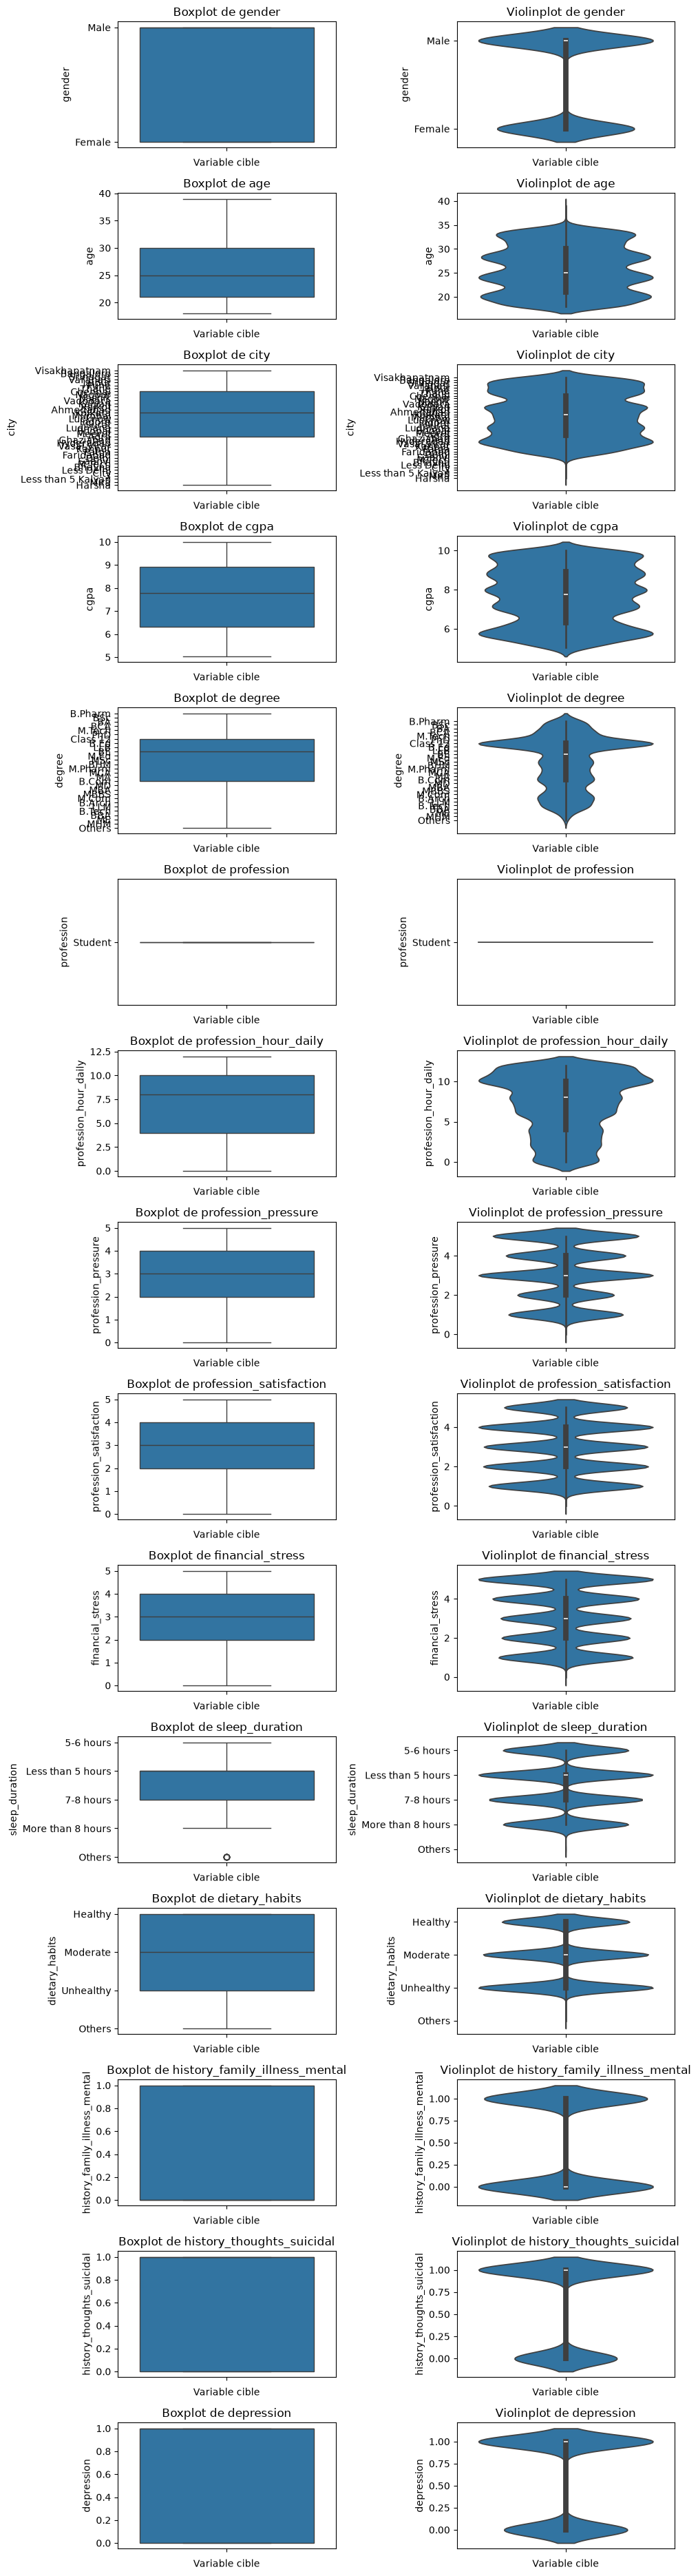

In [21]:
df_concat: pd.DataFrame = pd.concat(
    [df_X, df_Y],
    axis = 1)

list_col_num: list[str] = df_concat.select_dtypes(include = [np.number, np.bool, np.object_]).columns.tolist()

fig, ax = plt.subplots(
    nrows = len(list_col_num),
    ncols = 2,
    figsize = (10, (2.5 * len(list_col_num))))

subplot_row_index: int = 0
# Représentation graphique
for col_num in list_col_num:
    # Boxplot
    sns.boxplot(
        data = df_concat[col_num],
        ax = ax[subplot_row_index, 0],
        legend = False)
    ax[subplot_row_index, 0].set_xlabel("Variable cible")
    ax[subplot_row_index, 0].set_title(f"Boxplot de {col_num}")

    # Violinplot
    sns.violinplot(
        data = df_concat[col_num],
        ax = ax[subplot_row_index, 1],
        legend = False)
    ax[subplot_row_index, 1].set_xlabel("Variable cible")
    ax[subplot_row_index, 1].set_title(f"Violinplot de {col_num}")

    subplot_row_index += 1

plt.tight_layout()
plt.show()

## **Analyse bivariée**

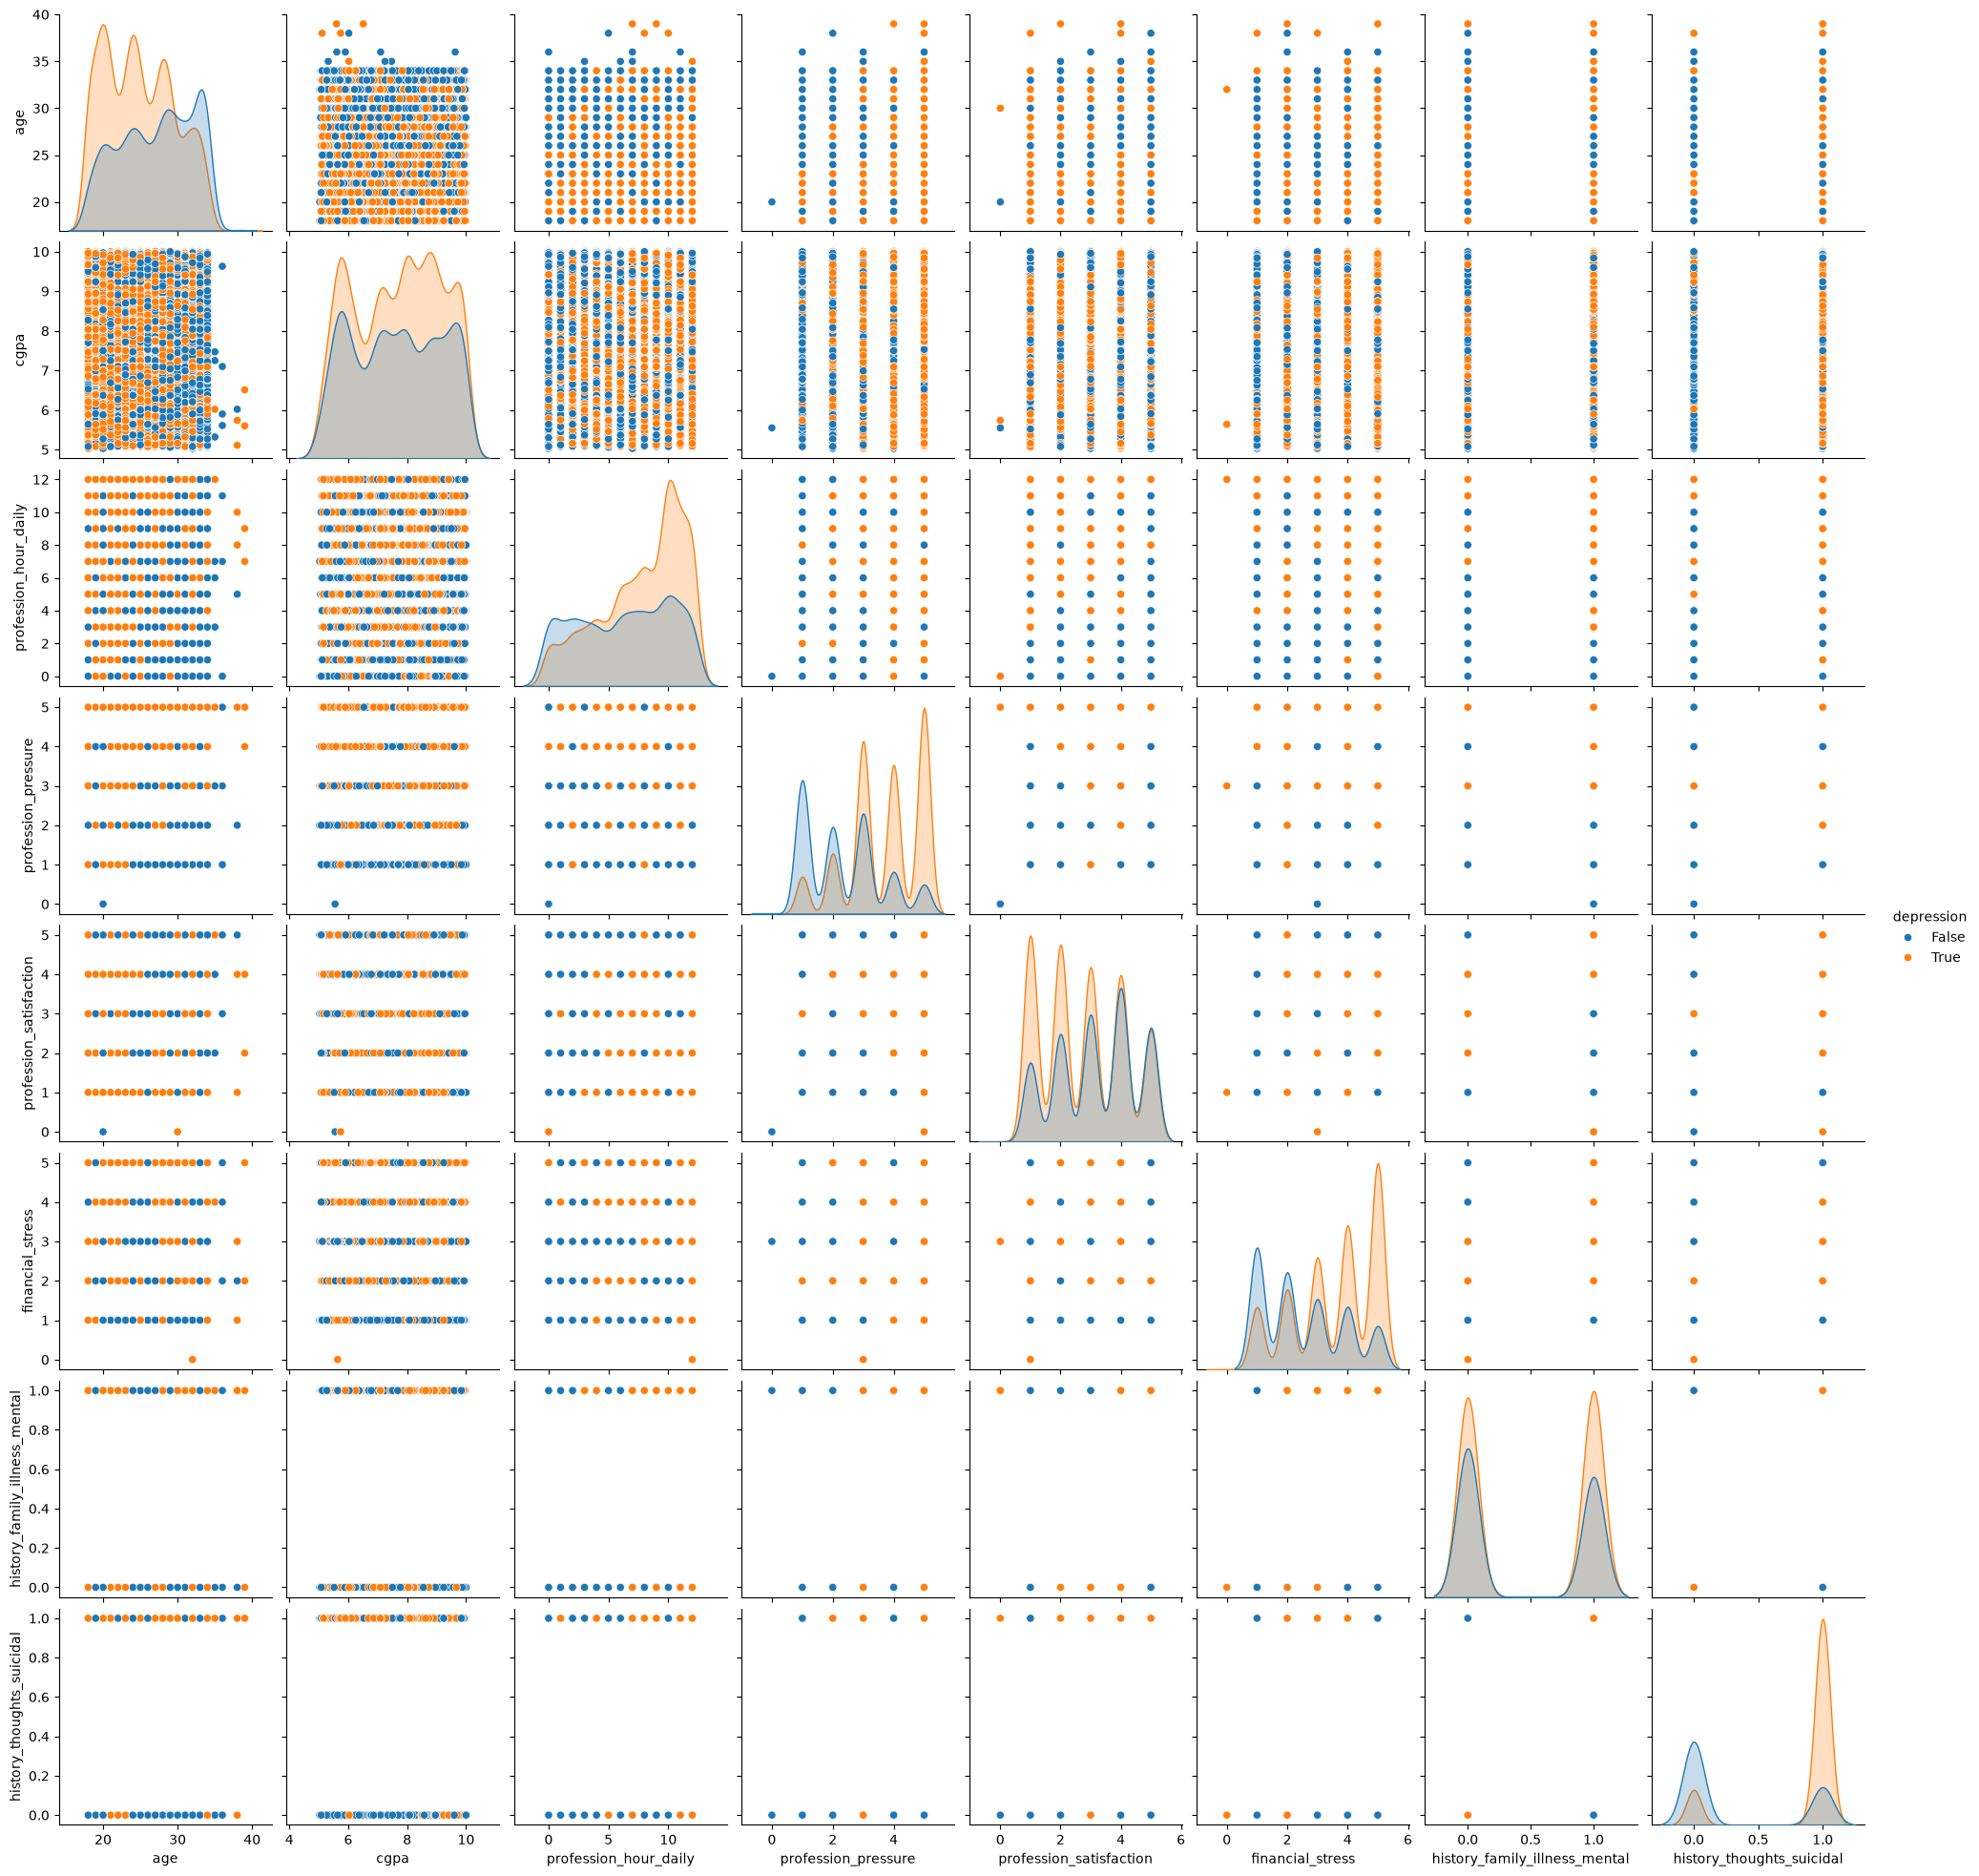

In [22]:
df_concat: pd.DataFrame = pd.concat([df_X, df_Y], axis=1)

sns.pairplot(
    data = df_concat,
    hue = "depression")

# **Machine Learning**

## **Chargement des librairies où sont implémentés les modèles évalués**

In [23]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
# Random forest
from sklearn.ensemble import RandomForestClassifier
# Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost as xgb
# SVM
from sklearn import svm
from sklearn.calibration import CalibratedClassifierCV

## **Répartition en subsets de "training" et de "test"**

12475 données dans le dataset:
- Train = 10000
- Test = 2475

In [24]:
# Récupération des index des datapoints séparés par la valeur de leur target
list_idx_depression_false: list[int] = list(df_X[df_Y.iloc[:,0]==False].index)
list_idx_depression_true: list[int] = list(df_X[df_Y.iloc[:,0]==True].index)

nb_test_target_tot: int = 2475
nb_test_target_true: int = math.ceil(nb_test_target_tot * 0.4)
nb_test_target_false: int = nb_test_target_tot - nb_test_target_true

# Index pour le subdataset "TEST"
list_idx_test_depression_false: list[int] = random.sample(
    population = list_idx_depression_false,
    k = nb_test_target_false)
list_idx_test_depression_true: list[int] = random.sample(
    population = list_idx_depression_true,
    k = nb_test_target_true)
# Index pour le subdataset "TRAIN"
list_idx_train_depression_false: list[int] = [idx for idx in list_idx_depression_false if (idx not in (list_idx_test_depression_false))]
list_idx_train_depression_true: list[int] = [idx for idx in list_idx_depression_true if (idx not in (list_idx_test_depression_true))]

list_idx_train: list[int] = list_idx_train_depression_false + list_idx_train_depression_true
list_idx_test: list[int] = list_idx_test_depression_false + list_idx_test_depression_true

list_idx_train.sort()
list_idx_test.sort()
print(f"list_idx_train: {len(list_idx_train)}")
print(list_idx_train)
print(f"list_idx_test: {len(list_idx_test)}")
print(list_idx_test)

list_idx_train: 10000
[0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 45, 46, 47, 49, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141, 142, 143, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 175, 176, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 191, 192, 193, 194, 195, 196, 197, 198, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 236, 237, 241, 242, 243, 244, 246, 2

In [25]:
# Datasets "TRAIN"
df_train_X: pd.DataFrame = df_X.iloc[list_idx_train]
df_train_Y: pd.DataFrame = df_Y.iloc[list_idx_train]
# Datasets "TEST"
df_test_X: pd.DataFrame = df_X.iloc[list_idx_test]
df_test_Y: pd.DataFrame = df_Y.iloc[list_idx_test]

# # Export des subdatasets pour ré-utilisation dans les prochains notebooks
# folder_dataset_path: Path = Path("./Dataset")
# file_dataset_train_path: Path = Path("df_train.csv")
# file_dataset_test_path: Path = Path("df_test.csv")

# df_train.to_csv(
#     path_or_buf = folder_dataset_path.joinpath(file_dataset_train_path),
#     sep = ",",
#     index = False)
# df_test.to_csv(
#     path_or_buf = folder_dataset_path.joinpath(file_dataset_test_path),
#     sep = ",",
#     index = False)

# Extraits des datasets
display(f"df_train_X: {df_train_X.shape}")
display(df_train_X.head(5))
display(f"df_train_Y: {df_train_Y.shape}")
display(df_train_Y.head(5))
display(f"df_test_X: {df_test_X.shape}")
display(df_test_X.head(5))
display(f"df_test_Y: {df_test_Y.shape}")
display(df_test_Y.head(5))

'df_train_X: (10000, 14)'

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
0,Male,33,Visakhapatnam,8.97,B.Pharm,Student,3,5,2,1,5-6 hours,Healthy,False,True
1,Female,24,Bangalore,5.90,BSc,Student,3,2,5,2,5-6 hours,Moderate,True,False
2,Male,31,Srinagar,7.03,BA,Student,9,3,5,1,Less than 5 hours,Healthy,True,False
3,Female,28,Varanasi,5.59,BCA,Student,4,3,2,5,7-8 hours,Moderate,True,True
4,Female,25,Jaipur,8.13,M.Tech,Student,1,4,3,1,5-6 hours,Moderate,False,True


'df_train_Y: (10000, 1)'

,depression
0,True
1,False
2,False
3,True
4,False


'df_test_X: (2475, 14)'

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
5,Male,29,Pune,5.70,PhD,Student,4,2,3,1,Less than 5 hours,Healthy,False,False
6,Male,30,Thane,9.54,BSc,Student,1,3,4,2,7-8 hours,Healthy,False,False
20,Male,29,Kolkata,8.74,B.Ed,Student,1,3,4,1,5-6 hours,Moderate,False,True
23,Male,23,Thane,8.59,BHM,Student,11,1,4,3,7-8 hours,Healthy,False,False
24,Male,18,Bangalore,7.10,Class 12,Student,11,4,3,5,More than 8 hours,Unhealthy,True,True


'df_test_Y: (2475, 1)'

,depression
5,False
6,False
20,False
23,False
24,True


In [26]:
print(f"Dimensions de df_train_X\n\t{df_train_X.shape}")
print(f"Dimensions de df_train_Y\n\t{df_train_Y.shape}")
print(f"Dimensions de df_test_X\n\t{df_test_X.shape}")
print(f"Dimensions de df_test_Y\n\t{df_test_Y.shape}")
print()
print(f"Distribution de df_train_Y\n\t{df_train_Y.value_counts(normalize=True).round(4).to_dict()}")
print(f"Distribution de df_test_Y\n\t{df_test_Y.value_counts(normalize=True).round(4).to_dict()}")

Dimensions de df_train_X
	(10000, 14)
Dimensions de df_train_Y
	(10000, 1)
Dimensions de df_test_X
	(2475, 14)
Dimensions de df_test_Y
	(2475, 1)

Distribution de df_train_Y
	{(True,): 0.6319, (False,): 0.3681}
Distribution de df_test_Y
	{(False,): 0.6, (True,): 0.4}


In [27]:
display(df_train_X.head(5))

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
0,Male,33,Visakhapatnam,8.97,B.Pharm,Student,3,5,2,1,5-6 hours,Healthy,False,True
1,Female,24,Bangalore,5.90,BSc,Student,3,2,5,2,5-6 hours,Moderate,True,False
2,Male,31,Srinagar,7.03,BA,Student,9,3,5,1,Less than 5 hours,Healthy,True,False
3,Female,28,Varanasi,5.59,BCA,Student,4,3,2,5,7-8 hours,Moderate,True,True
4,Female,25,Jaipur,8.13,M.Tech,Student,1,4,3,1,5-6 hours,Moderate,False,True


## **Stratification (Strafied K-Fold)**

In [28]:
# Stratification K-fold
nb_splits: int = 4

skf: StratifiedKFold = StratifiedKFold(
    n_splits = nb_splits,
    shuffle = True,
    random_state = rand_seed)


# Preview d'un split
skf_df_idx: Iterator[tuple[np.ndarray]] = skf.split(
    X = df_train_X,
    y = df_train_Y)
skf_df: pd.DataFrame = pd.DataFrame(skf_df_idx)

# split_idx: int = 0
# split_train_idx: list[int] = skf_df[0][split_idx]
# split_test_idx: list[int] = skf_df[1][split_idx]

# display("SPLIT #" + str(split_idx))
# display(f"TRAIN set: {split_train_idx.shape}")
# display(df_train_X.iloc[split_train_idx].head(5))
# display(f"TEST set: {split_test_idx.shape}")
# display(df_train_X.iloc[split_test_idx].head(5))


# for i in range(nb_splits):
#     display("SPLIT #" + str(i))
#     split_train_idx: list[int] = skf_df[0][i]
#     split_test_idx: list[int] = skf_df[1][i]

#     display(f"TRAIN set: {split_train_idx.shape}")
#     display(df.iloc[split_train_idx].head(5))
#     display(f"TEST set: {split_test_idx.shape}")
#     display(df.iloc[split_test_idx].head(5))

## **Conception du pipeline de transformation de la donnée**

In [29]:
# # Définition des "casters"
# transformer_ensure_str: TransformerMixin = FunctionTransformer(df_ensure_str)
# transformer_ensure_int: TransformerMixin = FunctionTransformer(df_ensure_int)
# transformer_ensure_float: TransformerMixin = FunctionTransformer(df_ensure_float)
# transformer_ensure_bool: TransformerMixin = FunctionTransformer(df_ensure_bool)
# transformer_ensure_label: TransformerMixin = FunctionTransformer(df_ensure_label)


# Définition des imputers
imputer_number_mean: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "mean")
imputer_number_median: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "median")
imputer_number_mode: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "most_frequent")
imputer_string_mode: SimpleImputer = SimpleImputer(
    strategy = "constant",
    fill_value = "○○○")


# Définition des normalisers
normaliser_minmaxscaling: MinMaxScaler = MinMaxScaler()
normaliser_standardisation: StandardScaler = StandardScaler()
normaliser_onehotencoding: OneHotEncoder = OneHotEncoder(handle_unknown = "ignore")


# Création des transformers
transformer_bool: Pipeline = make_pipeline(
    # transformer_ensure_bool,
    # imputer_number_mode
)
transformer_label: Pipeline = make_pipeline(
    # transformer_ensure_label,
    normaliser_onehotencoding
)
transformer_float: Pipeline = make_pipeline(
    # transformer_ensure_float,
    imputer_number_median,
    normaliser_standardisation
)
transformer_int: Pipeline = make_pipeline(
    # transformer_ensure_int,
    imputer_number_median,
    normaliser_minmaxscaling
)

col_type_bool: list[str] = ["history_family_illness_mental", "history_thoughts_suicidal", "depression"]
col_type_label: list[str] = ["gender", "degree", "profession", "sleep_duration", "dietary_habits"]
col_type_string: list[str] = ["city"]
col_type_float: list[str] = ["cgpa"]
col_type_int: list[str] = ["age", "profession_hour_daily", "profession_pressure", "profession_satisfaction", "financial_stress"]

# Création du transformer global
preprocesseur: ColumnTransformer = ColumnTransformer(
    transformers = [
        # ("transform_history_family_illness_mental", transformer_bool, ["history_family_illness_mental"]),
        # ("transform_history_thoughts_suicidal", transformer_bool, ["history_thoughts_suicidal"]),
        # ("transform_depression", transformer_bool, ["depression"]),

        ("transform_gender", transformer_label, ["gender"]),
        ("transform_degree", transformer_label, ["degree"]),
        ("transform_profession", transformer_label, ["profession"]),
        ("transform_sleep_duration", transformer_label, ["sleep_duration"]),
        ("transform_dietary_habits", transformer_label, ["dietary_habits"]),

        ("transform_cgpa", transformer_float, ["cgpa"]),

        ("transform_age", transformer_int, ["age"]),
        ("transform_profession_hour_daily", transformer_int, ["profession_hour_daily"]),
        ("transform_profession_pressure", transformer_int, ["profession_pressure"]),
        ("transform_profession_satisfaction", transformer_int, ["profession_satisfaction"]),
        ("transform_financial_stress", transformer_int, ["financial_stress"])
    ]
)

# preprocesseur: ColumnTransformer = ColumnTransformer(
#     transformers = [
#         ("transform_int", transformer_int, col_type_int),
#         ("transform_float", transformer_float, col_type_float),
#         ("transform_bool", transformer_bool, col_type_bool),
#         ("transform_label", transformer_label, col_type_label)
#     ]
# )

# preprocesseur: ColumnTransformer = make_column_transformer(
#     (transformer_int, col_type_int),
#     (transformer_float, col_type_float),
#     (transformer_bool, col_type_bool),
#     (transformer_label, col_type_label)
# )

## **Préparation des fonctions qui seront employées lors des entraînements / optimisations / évaluations**

In [30]:
def model_fit(
    df_X: pd.DataFrame,
    df_Y: pd.Series,
    preprocessor: ColumnTransformer,
    estimator: ClassifierMixin | Pipeline | LogisticRegression,
    **kwargs
    ) -> Pipeline:
        model: Pipeline = Pipeline(
            steps = [
                ("preprocesseur", preprocessor),
                ("estimateur", estimator)
            ]
        )

        return model.fit(df_X, df_Y, **kwargs)



def model_crossvalidation(
    model: Pipeline,
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    df_test_X: pd.DataFrame,
    df_test_Y: pd.Series
    ) -> dict[str,float]:
        # # Prédiction des probabilités
        # pred_train_Y = model.predict_proba(df_train_X)[:, 1]
        # pred_test_Y = model.predict_proba(df_test_X)[:, 1]

        # # Calcul des AUC
        # auc_train = roc_auc_score(df_train_Y, pred_train_Y)
        # auc_test = roc_auc_score(df_test_Y, pred_test_Y)

        # return auc_train, auc_test


        list_metrics_name: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]

        # Entrainement des modèles
        dict_scores: dict[str, float] = cross_validate(
            estimator = model,
            X = df_train_X,
            y = df_train_Y,
            cv = skf,
            scoring = list_metrics_name)
        
        dict_metric_mean: dict[str,float] = {score_name: round(np.mean(list_score_val)*100, 2) for (score_name, list_score_val) in dict_scores.items()}

        return dict_metric_mean



def model_optimise(
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    preprocessor: ColumnTransformer,
    estimator: Pipeline,
    param_grid: Mapping | Sequence[Mapping],
    c_v_split_strat: any,
    list_metrics: list
    ) -> dict:
        model: Pipeline = Pipeline(
            steps = [
                ("preprocesseur", preprocessor),
                ("estimateur", estimator)
            ]
        )

        # GridSearchCV
        # Instanciation d'un objet "GridSearchCV"
        search_hyperparam_gridSearch: GridSearchCV = GridSearchCV(
            estimator = model,
            param_grid = param_grid,
            cv = c_v_split_strat,
            n_jobs = -1,
            verbose = 1,
            scoring = list_metrics,
            refit = "roc_auc")

        search_hyperparam_gridSearch.fit(df_train_X, df_train_Y)

        display("best_score_")
        display(search_hyperparam_gridSearch.best_score_)
        display("best_params_")
        display(search_hyperparam_gridSearch.best_params_)

        dict_bestparams: dict = {
            key.replace("estimateur__", "") : val for (key, val) in search_hyperparam_gridSearch.best_params_.items()
        }
        
        
        dict_return: dict = {
            "Pipeline":
                estimator.set_params(**dict_bestparams),
            "GridSearchCV":
                search_hyperparam_gridSearch }

        return dict_return



def model_evaluation(
    model: Pipeline,
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    df_test_X: pd.DataFrame,
    df_test_Y: pd.Series
    ) -> tuple[float, float]:
        # Prédiction des probabilités
        df_train_Y_pred = model.predict_proba(df_train_X)[:, 1]
        df_test_Y_pred = model.predict_proba(df_test_X)[:, 1]

        # Calcul des AUC
        auc_train: float = roc_auc_score(df_train_Y, df_train_Y_pred)
        auc_test: float = roc_auc_score(df_test_Y, df_test_Y_pred)

        return auc_train, auc_test

## **Entraînement (pré-optimisation)**

### **Instanciation des modèles**

In [31]:
nb_jobs: int = 4

# Logistic regression
model_logreg: LogisticRegression = LogisticRegression(
    class_weight = "balanced",
    max_iter = 500,
    random_state = rand_seed )

# Random forest
model_randforest: RandomForestClassifier = RandomForestClassifier(
    class_weight = "balanced",
    n_estimators = 100,
    n_jobs = nb_jobs,
    random_state = rand_seed )

# Gradient boosting
model_gradboost: GradientBoostingClassifier = GradientBoostingClassifier(
    n_estimators = 100,
    random_state = rand_seed )

# XGBoost
model_xgboost: xgb.XGBClassifier = xgb.XGBClassifier(
    n_jobs = nb_jobs,
    random_state = rand_seed )

# SVM
model_svm: svm.SVC = CalibratedClassifierCV(
    svm.SVC(
        class_weight = "balanced",
        kernel = "sigmoid",
        random_state = rand_seed ),
    ensemble = True )



# Dictionnaire qui permettra d'itérer sur les modèles
dict_model: dict[str, ClassifierMixin] = {
    "model_logreg": model_logreg,
    "model_randforest": model_randforest,
    "model_gradboost": model_gradboost,
    "model_xgboost": model_xgboost,
    "model_svm": model_svm }

## **Evaluation (pré-optimisation)**

### **Appréciation des performances et de la capacité à généraliser des modèles via cross-validation**

In [32]:
# Bouclez sur chacun des modèles
dict_metric_by_model: dict[str,dict[str,float]] = {}
for (model_name, model) in dict_model.items():
    # Entraînez le modèle
    fit_m = model_fit(
        df_X = df_X,
        df_Y = df_Y.iloc[:,0],
        preprocessor = preprocesseur,
        estimator = model )
    
    # Calculez les AUC du train et du test
    dict_metric = model_crossvalidation(
        model = fit_m,
        df_train_X = df_train_X,
        df_train_Y = df_train_Y.iloc[:,0],
        df_test_X = df_test_X,
        df_test_Y = df_test_Y.iloc[:,0] )

    dict_metric_by_model[model_name] = dict_metric

    # # Affichez pour chaque modèle les AUC de train et de test
    # print(f"AUC {model_name} : {round(evaluation[0], 4)} (train)",
    #       f"{round(evaluation[1], 4)} (test)")

### **Affichage des métriques par modèle**

In [33]:
from pandas.io.formats.style import Styler

df_metrics_by_model_full: pd.DataFrame = pd.DataFrame(dict_metric_by_model)
df_metrics_by_model: pd.DataFrame = df_metrics_by_model_full.drop(
    labels = ["fit_time", "score_time"],
    axis = "index" )

metrics_by_model_visualiser: Styler = df_metrics_by_model.style.background_gradient(cmap='RdYlGn')

display(metrics_by_model_visualiser)

,model_logreg,model_randforest,model_gradboost,model_xgboost,model_svm
test_accuracy,78.710000,79.020000,80.100000,77.970000,69.170000
test_precision,86.400000,84.340000,82.230000,81.280000,70.540000
test_recall,78.710000,82.040000,87.400000,84.620000,87.960000
test_f1,82.370000,83.170000,84.730000,82.920000,78.260000
test_roc_auc,86.730000,85.630000,86.740000,84.280000,71.350000


## **Optimisation**

### **Dictionnaire des hyperparamètres à parcourir lors de la GridSearch**

In [34]:
# Dictionnaire de paramètres dont les valeurs sont à sélectionner

### Long GridSearch
### Long GridSearch
### Long GridSearch

# # Pour model_logreg
# param_gridsearch: dict = {
#     "estimateur__l1_ratio" : [0, 1],
#     "estimateur__C" : [10**exponent for exponent in np.linspace(-1, 1, 3, dtype=float)],
#     # "l1_ratio" : list(np.linspace(0, 1, 3, dtype=float)),
#     "estimateur__dual" : [False, True],
#     "estimateur__tol" : [10**exponent for exponent in np.linspace(-5, -3, 3, dtype=float)],
#     "estimateur__fit_intercept" : [False, True],
#     "estimateur__intercept_scaling" : list(np.linspace(0, 2, 3, dtype=float)),
#     "estimateur__class_weight" : [
#         None,
#         "balanced"],
#     "estimateur__solver" : ["lbfgs", "liblinear"],
#     "estimateur__max_iter" : list(np.linspace(300, 700, 3, dtype=int)) }


# Pour model_gradboost
# param_gridsearch: dict = {
#     "estimateur__loss":['exponential', 'log_loss'],
#     "estimateur__learning_rate": [0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2],
#     "estimateur__min_samples_split": np.linspace(0.1, 0.5, 5),
#     "estimateur__min_samples_leaf": np.linspace(0.1, 0.5, 5),
#     "estimateur__max_depth":[(2 * multi) for multi in range(1,6)],
#     "estimateur__max_features":["log2", "sqrt"],
#     "estimateur__criterion": ["squared_error", "friedman_mse"],
#     "estimateur__subsample":[(0.25 * multi) for multi in range(1,5)],
#     "estimateur__n_estimators":[(25 * multi) for multi in range(1,5)] }

param_gridsearch: dict = {
    'estimateur__criterion': ['squared_error'],
    'estimateur__learning_rate': [0.2],
    'estimateur__loss': ['log_loss'],
    'estimateur__max_depth': [2],
    'estimateur__max_features': ['sqrt'],
    'estimateur__min_samples_leaf': [np.float64(0.1)],
    'estimateur__min_samples_split': [np.float64(0.1)],
    'estimateur__n_estimators': [100],
    'estimateur__subsample': [0.75] }

### **Optimisation des hyperparamètres (GridSearch déterministe)**

In [35]:
# # GridSearchCV
# list_metrics_name: list[str] = ["roc_auc"]
# # list_metrics_name: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]
# # Instanciation d'un objet "GridSearchCV"
# search_hyperparam_gridSearch: GridSearchCV = GridSearchCV(
#     # estimator = LogisticRegression(random_state = rand_seed),
#     estimator = GradientBoostingClassifier(random_state = rand_seed),
#     param_grid = param_gridsearch,
#     cv = skf,
#     n_jobs = -1,
#     verbose = 1,
#     scoring = list_metrics_name,
#     refit = "roc_auc" )

# # # Entraînement et évaluation du modèle
# # logreg_model = model_fit(df_train_X, df_train_Y, search_hyperparam_gridSearch)

# # evaluation = model_evaluation(
# #     model = logreg_model,
# #     df_train_X = df_train_X,
# #     df_train_Y = df_train_Y,
# #     df_train_Y = df_test_X,
# #     df_test_Y = df_test_Y )

# # print(f"AUC Train : {evaluation[0]:.4f}")
# # print(f"AUC Test  : {evaluation[1]:.4f}")

In [36]:
# Les "warnings" vont être temporairement désactivés, car les combinaisons non-valides vont en générer
import warnings
warnings.filterwarnings("ignore")

In [37]:
from copy import deepcopy

# Choix du modèle de base, avec ses hyperparamètres par défaut (Gradien Boosting)
model_base: GradientBoostingClassifier = GradientBoostingClassifier(random_state = rand_seed)

# Instanciation du modèle AVANT entraînement
model_AVANT_opti: GradientBoostingClassifier = deepcopy(model_base)
# Instanciation du modèle APRES entraînement
model_APRES_opti: GradientBoostingClassifier = deepcopy(model_base)

In [38]:
dict_return_model_optimise = model_optimise(
    df_train_X = df_train_X,
    df_train_Y = df_train_Y.iloc[:, 0],
    preprocessor = preprocesseur,
    estimator = GradientBoostingClassifier(random_state = rand_seed),
    param_grid = param_gridsearch,
    c_v_split_strat = skf,
    list_metrics = ["roc_auc"] )

model_bestparams: Pipeline = dict_return_model_optimise["Pipeline"]
search_hyperparam_gridSearch: GridSearchCV = dict_return_model_optimise["GridSearchCV"]

Fitting 4 folds for each of 1 candidates, totalling 4 fits


'best_score_'

np.float64(0.8686856637257596)

'best_params_'

{'estimateur__criterion': 'squared_error',
 'estimateur__learning_rate': 0.2,
 'estimateur__loss': 'log_loss',
 'estimateur__max_depth': 2,
 'estimateur__max_features': 'sqrt',
 'estimateur__min_samples_leaf': np.float64(0.1),
 'estimateur__min_samples_split': np.float64(0.1),
 'estimateur__n_estimators': 100,
 'estimateur__subsample': 0.75}

In [39]:
# Affichage des résultats obtenus
print(f"Meilleurs paramètres:\n\t{search_hyperparam_gridSearch.best_params_}")
print(f"Meilleur score de cross-validation:\n\t{search_hyperparam_gridSearch.best_score_:.4f}")
print(f"Test set score:\n\t{search_hyperparam_gridSearch.score(df_test_X, df_test_Y):.4f}")


warnings.filterwarnings("default")

Meilleurs paramètres:
	{'estimateur__criterion': 'squared_error', 'estimateur__learning_rate': 0.2, 'estimateur__loss': 'log_loss', 'estimateur__max_depth': 2, 'estimateur__max_features': 'sqrt', 'estimateur__min_samples_leaf': np.float64(0.1), 'estimateur__min_samples_split': np.float64(0.1), 'estimateur__n_estimators': 100, 'estimateur__subsample': 0.75}
Meilleur score de cross-validation:
	0.8687
Test set score:
	0.8647


In [40]:
# # Recherche des hyperparamètres via GridSearch
# search_hyperparam_gridSearch.fit(df_train_X, df_train_Y)

# # Affichage des résultats obtenus
# print(f"Meilleurs paramètres:\n\t{search_hyperparam_gridSearch.best_params_}")
# print(f"Meilleur score de cross-validation:\n\t{search_hyperparam_gridSearch.best_score_:.4f}")
# print(f"Test set score:\n\t{search_hyperparam_gridSearch.score(df_test_X, df_test_Y):.4f}")

# warnings.filterwarnings("default")

# # # Comparaison des hyperparamètres
# # dict_hyperpara: dict[str,dict] = {
# #     "AVANT" : model_logreg_base.get_params(),
# #     "APRES": search_hyperparam_gridSearch.best_params_}
# # df_hyperpara: pd.DataFrame = pd.DataFrame(dict_hyperpara)
# # display(df_hyperpara)

In [41]:
search_hyperparam_gridSearch.best_params_ = {
    key.replace("estimateur__", "") : val for (key, val) in search_hyperparam_gridSearch.best_params_.items()
}

# AVANT: fit du modèle avec les hyperparamètres par défaut
model_AVANT_opti = model_fit(
    df_X = df_train_X,
    df_Y = df_train_Y.iloc[:,0],
    preprocessor = preprocesseur,
    estimator = model_AVANT_opti )

# APRES: fit du modèle avec les hyperparamètres optimaux trouvés via GridSearch
model_APRES_opti = model_APRES_opti.set_params(**search_hyperparam_gridSearch.best_params_)
model_APRES_opti = model_fit(
    df_X = df_train_X,
    df_Y = df_train_Y.iloc[:,0],
    preprocessor = preprocesseur,
    estimator = model_APRES_opti )

# Comparaison des hyperparamètres des modèles
dict_hyperparam: dict[str,dict] = {
    "AVANT" : model_AVANT_opti.get_params(),
    "APRES": model_APRES_opti.get_params()}
df_hyperparam: pd.DataFrame = pd.DataFrame(dict_hyperparam)
display("Comparaison des hyperparamètres, avant et après optimisation")
display(df_hyperparam)

c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_gb.py:666: FutureWarning: The parameter `criterion` is deprecated and will be removed in 1.11. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


'Comparaison des hyperparamètres, avant et après optimisation'

,AVANT,APRES
memory,None,None
steps,"[(preprocesseur, ColumnTransformer(transformer...","[(preprocesseur, ColumnTransformer(transformer..."
transform_input,None,None
verbose,False,False
preprocesseur,ColumnTransformer(transformers=[('transform_ge...,ColumnTransformer(transformers=[('transform_ge...
...,...,...
estimateur__subsample,1.0,0.75
estimateur__tol,0.0001,0.0001
estimateur__validation_fraction,0.1,0.1
estimateur__verbose,0,0


##### *Calcul des différentes métriques, via cross-validation (sur les données d'entraînement)*

In [42]:
dict_model: dict[str, ClassifierMixin] = {
    "model_AVANT_opti" : model_AVANT_opti,
    "model_APRES_opti" : model_APRES_opti}

# Liste des métriques (scores) à mesurer
list_metrics_name: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Dictionnaire qui va stocker, par modèle, les scores obtenus pour les différentes métriques
dict_metric_by_model: dict[str,dict[str,float]] = {}

# Entrainement des modèles
for (model_name, model_object) in dict_model.items():
    dict_scores: dict[str, float] = cross_validate(
        estimator = model_object,
        X = df_train_X,
        y = df_train_Y,
        cv = skf,
        scoring = list_metrics_name)
    
    dict_metric_mean: dict[str,float] = {score_name: round(list_score_val.mean()*100, 2) for (score_name, list_score_val) in dict_scores.items()}
    
    dict_metric_by_model[model_name] = dict_metric_mean

c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.p

In [43]:
from pandas.io.formats.style import Styler

df_metrics_by_model_full: pd.DataFrame = pd.DataFrame(dict_metric_by_model)
df_metrics_by_model: pd.DataFrame = df_metrics_by_model_full.drop(
    labels = ["fit_time", "score_time"],
    axis = 0)

metrics_by_model_visualiser: Styler = df_metrics_by_model.style.background_gradient(cmap='RdYlGn')

display(metrics_by_model_visualiser)

,model_AVANT_opti,model_APRES_opti
test_accuracy,80.100000,80.070000
test_precision,82.230000,81.990000
test_recall,87.400000,87.740000
test_f1,84.730000,84.760000
test_roc_auc,86.740000,86.870000


##### *Comparaison des scores "roc_auc", courbes ROC et matrices de confusion, obtenus sur les données de test*

'roc_auc_score'

,model_AVANT_opti,model_APRES_opti
roc_auc_score,0.862683,0.864724


'roc_curve'

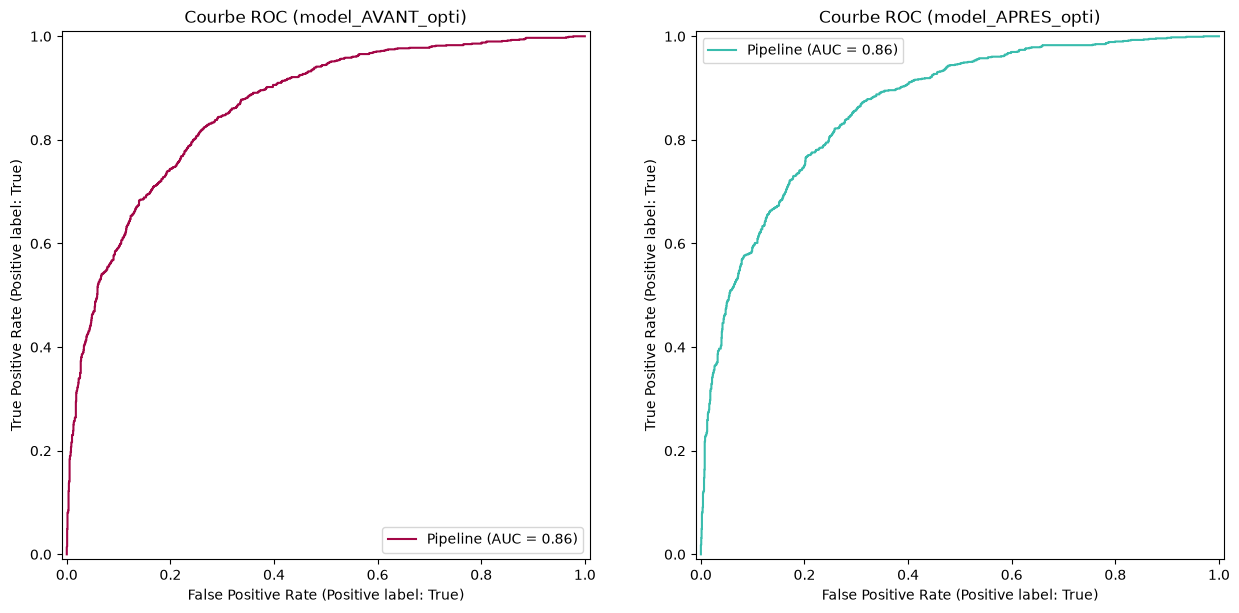

'precision_recall_curve'

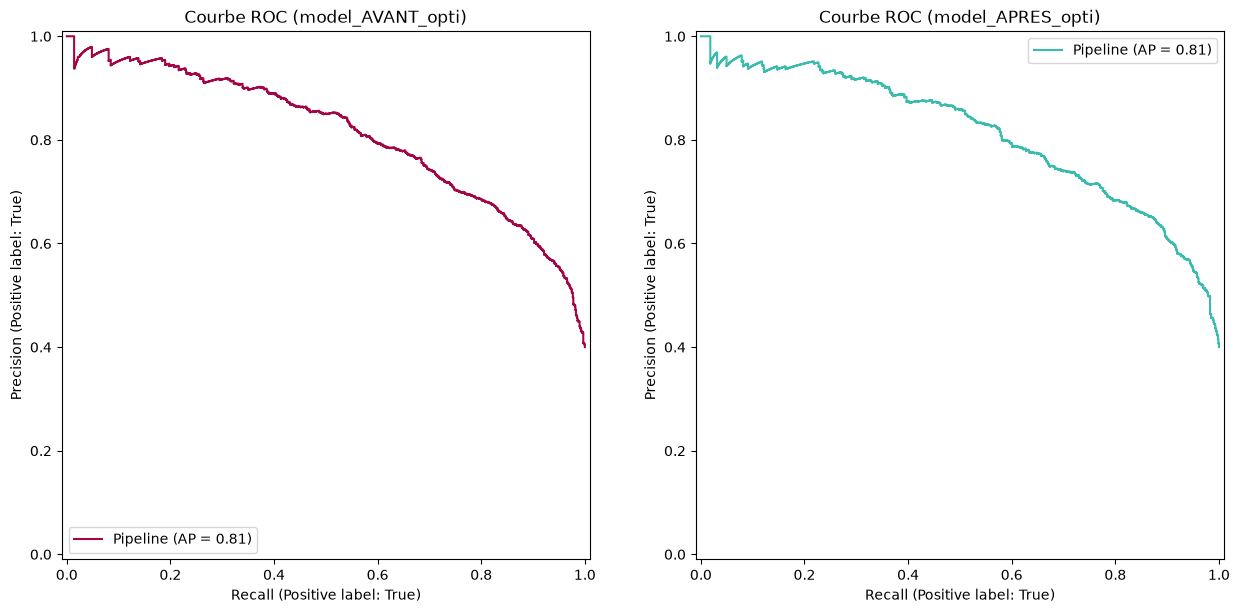

'confusion_matrix'

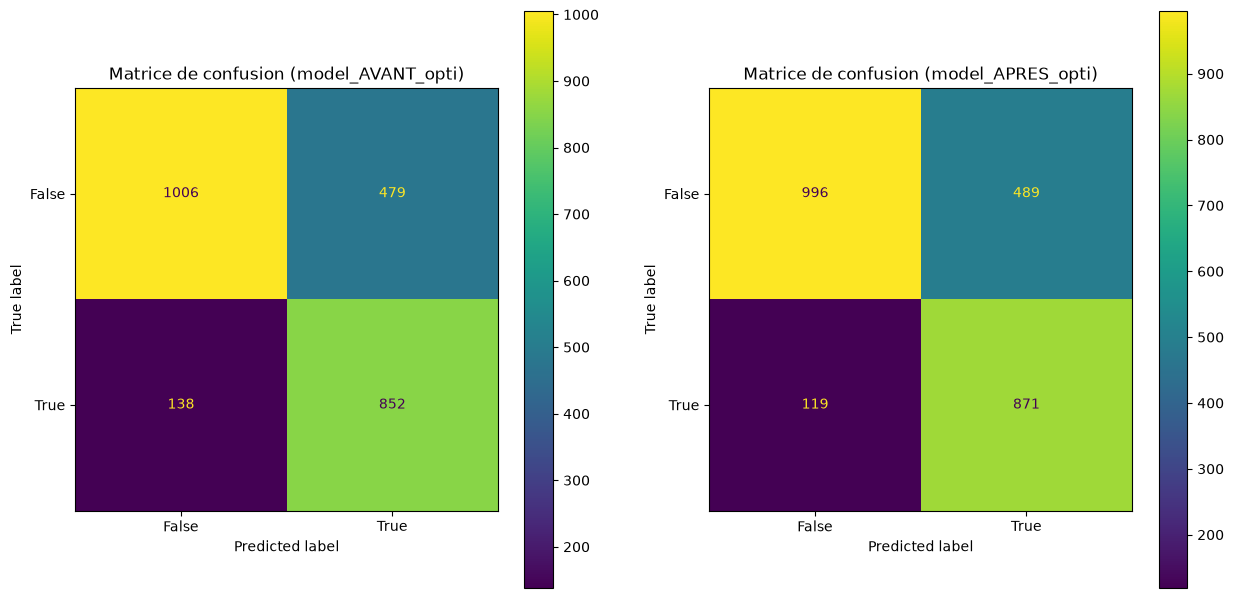

'calibration_curve'

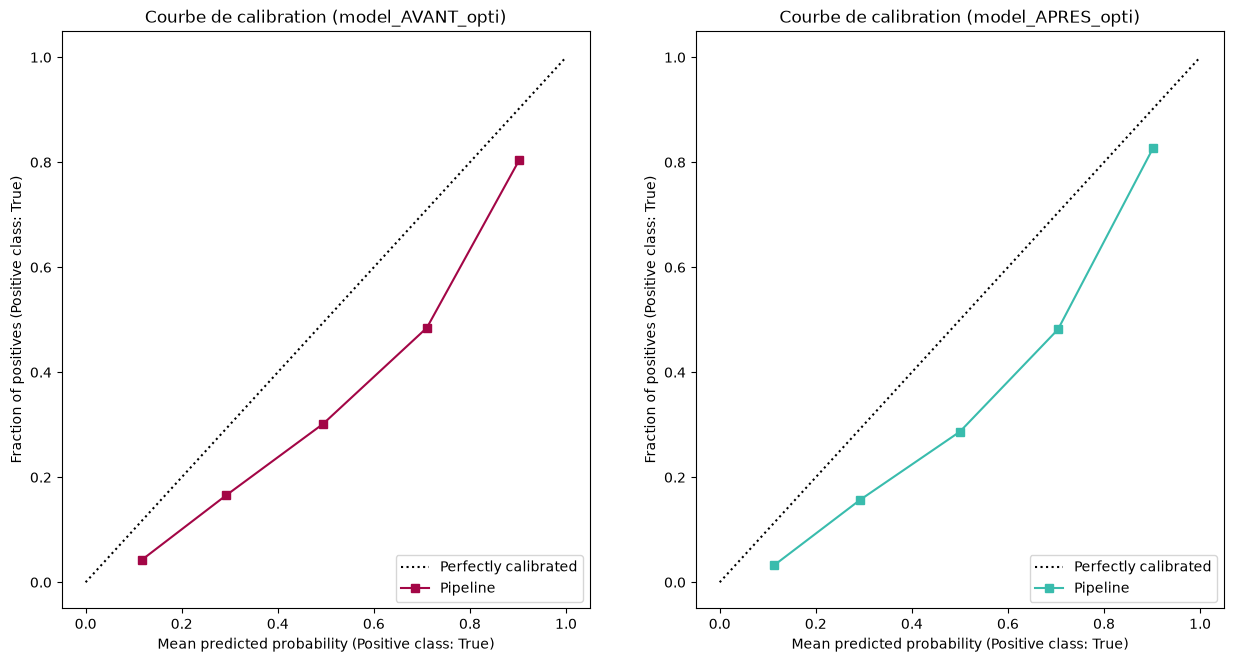

In [44]:
random.seed(rand_seed)

# Génération de couleurs RGB aléatoires pour les courbes
tuple_graph_color: tuple[tuple[float]] = tuple(tuple([random.random() for __ in range(3)] for _ in range(len(dict_model.keys()))))



### roc_auc_score
dict_rocaucscore_by_model: dict[str,dict] = {}

for (model_name, model_object) in dict_model.items():
    dict_rocaucscore_by_model[model_name] = {}
    dict_rocaucscore_by_model[model_name]["roc_auc_score"] = roc_auc_score(
        y_true = df_test_Y,
        y_score = model_object.predict_proba(df_test_X)[:, 1])

df_rocaucscore_by_model: pd.DataFrame = pd.DataFrame(dict_rocaucscore_by_model)

display("roc_auc_score")
display(df_rocaucscore_by_model)



### roc_curve
fig_roccurve, axs_roccurve = plt.subplots(
    nrows = 1,
    ncols = len(dict_model.keys()),
    figsize = (15,7.5))

for (index, (model_name, model_object)) in enumerate(dict_model.items()):
    RocCurveDisplay.from_estimator(
        estimator = model_object,
        X = df_test_X,
        y = df_test_Y,
        ax = axs_roccurve[index],
        # name = f"Courbe ROC ({model_name})",
        curve_kwargs = {
            "color" : tuple_graph_color[index]
        }
    ).ax_.set_title(
        label = f"Courbe ROC ({model_name})")

plt.legend()
display("roc_curve")
plt.show()



# precision_recall_curve
fig_precisionrecall, axs_precisionrecall = plt.subplots(
    nrows = 1,
    ncols = len(dict_model.keys()),
    figsize = (15,7.5))

for (index, (model_name, model_object)) in enumerate(dict_model.items()):
    PrecisionRecallDisplay.from_estimator(
        estimator = model_object,
        X = df_test_X,
        y = df_test_Y,
        ax = axs_precisionrecall[index],
        # name = f"Courbe ROC ({model_name})",
        curve_kwargs = {
            "color" : tuple_graph_color[index]
        }
    ).ax_.set_title(
        label = f"Courbe ROC ({model_name})")

plt.legend()
display("precision_recall_curve")
plt.show()



### confusion_matrix
fig_confmat, axs_confmat = plt.subplots(
    nrows = 1,
    ncols = len(dict_model.keys()),
    figsize = (15,7.5))

for (index, (model_name, model_object)) in enumerate(dict_model.items()):
    ConfusionMatrixDisplay.from_estimator(
        estimator = model_object,
        X = df_test_X,
        y = df_test_Y,
        ax = axs_confmat[index]
    ).ax_.set_title(
        label = f"Matrice de confusion ({model_name})")

display("confusion_matrix")
plt.show()



### calibration_curve
fig_calcur, axs_calcur = plt.subplots(
    nrows = 1,
    ncols = len(dict_model.keys()),
    figsize = (15,7.5))

# prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
# disp = CalibrationDisplay(prob_true, prob_pred, y_prob)

for (index, (model_name, model_object)) in enumerate(dict_model.items()):
    CalibrationDisplay.from_estimator(
        estimator = model_object,
        X = df_test_X,
        y = df_test_Y,
        ax = axs_calcur[index],
        color = tuple_graph_color[index]
    ).ax_.set_title(
        label = f"Courbe de calibration ({model_name})")

display("calibration_curve")
plt.show()

In [45]:
# Packages scikit-learn pour modélisation
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# # Interprétabilité des modèles avec SHAP
# import shap



r = permutation_importance(
    estimator = model_APRES_opti,
    X = df_test_X,
    y = df_test_Y,
    n_repeats = 30,
    random_state = rand_seed )

# display(model_APRES_opti)

for i in r.importances_mean.argsort()[::-1]:
    if ((r.importances_mean[i] - r.importances_std[i]) > 0):
    # if (r.importances_mean[i] > 0.05):
        print(
            f"{df_test_X.columns[i]}\n\t"
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}" )

profession_pressure
	0.122 +/- 0.006
financial_stress
	0.060 +/- 0.007
profession_hour_daily
	0.021 +/- 0.005
dietary_habits
	0.019 +/- 0.004
age
	0.018 +/- 0.004
profession_satisfaction
	0.009 +/- 0.003
sleep_duration
	0.005 +/- 0.003


'feature_importance'

['gender', 'age', 'city', 'cgpa', 'degree', 'profession', 'profession_hour_daily', 'profession_pressure', 'profession_satisfaction', 'financial_stress', 'sleep_duration', 'dietary_habits', 'history_family_illness_mental', 'history_thoughts_suicidal']
[ 0.          0.01787205  0.         -0.00056566 -0.00191246  0.
  0.0156229   0.12468687  0.00324579  0.05206734  0.00284175  0.01295623
  0.          0.        ]
[-1.07744108e-04  1.81548822e-02  0.00000000e+00  6.32996633e-04
  1.01010101e-03  0.00000000e+00  2.07407407e-02  1.21750842e-01
  8.75420875e-03  6.03501684e-02  4.57912458e-03  1.93939394e-02
  0.00000000e+00  0.00000000e+00]


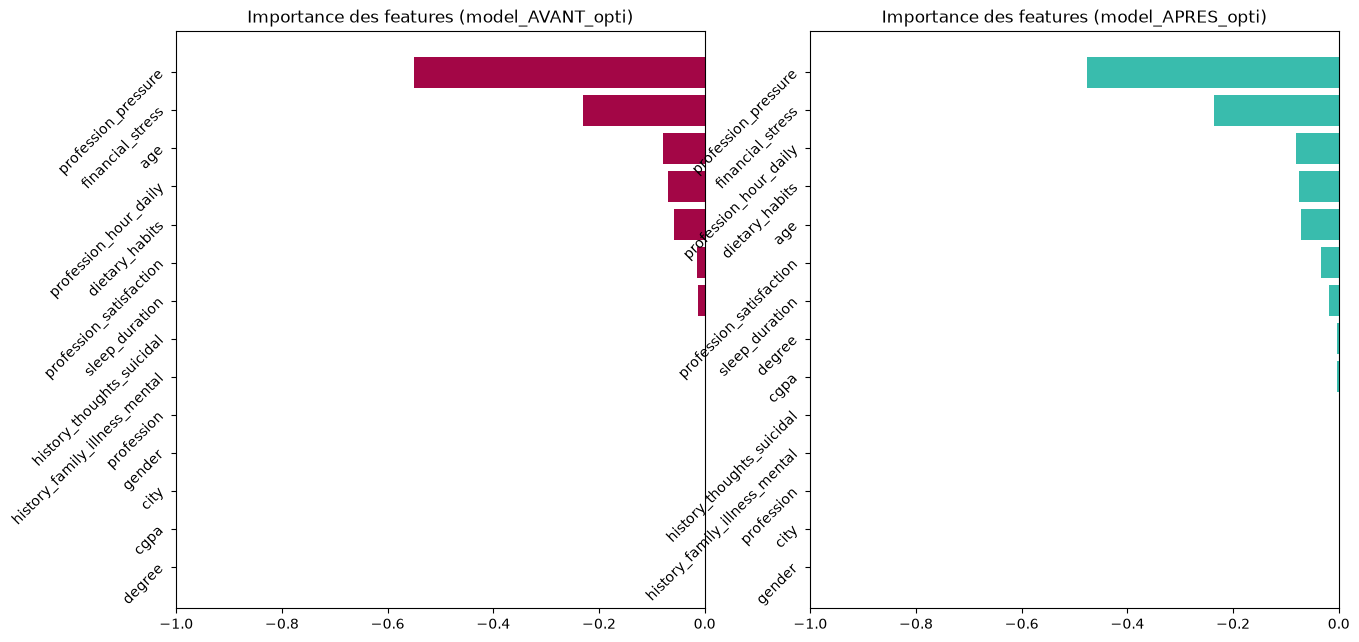

In [46]:
### feature_importance
fig_featimp, axs_featimp = plt.subplots(
    nrows = 1,
    ncols = len(dict_model.keys()),
    figsize = (15,7.5))


display("feature_importance")
print(list(df_train_X.columns))
for (index, (model_name, model_object)) in enumerate(dict_model.items()):
    r = permutation_importance(
        estimator = model_object,
        X = df_test_X,
        y = df_test_Y,
        n_repeats = 30,
        random_state = rand_seed )

    print(r.importances_mean)

    importances_mean: np.ndarray = np.array(r.importances_mean)
    sum_importances_mean: float = importances_mean.sum()
    importance_mean_percent_overall: np.ndarray = importances_mean / sum_importances_mean

    feature_name: list[str] = list(df_train_X.columns)
    feature_importance: list[float] = -importance_mean_percent_overall
    # df_featimp: pd.DataFrame = pd.DataFrame(
    #     data = {feature_name[index] : feature_importance[index] for index in range(len(feature_name))},
    #     index = [0])
    df_featimp: pd.DataFrame = pd.DataFrame(
        data = {
            "feature_name" : feature_name,
            "feature_importance" : feature_importance}).sort_values(
                by = ["feature_importance"],
                ascending = False)

    axs_featimp[index].set_title(label = f"Importance des features ({model_name})")
    axs_featimp[index].set_xlim(-1,0)
    axs_featimp[index].tick_params(
        axis = "y",
        rotation = 45)
    axs_featimp[index].barh(
        y = df_featimp["feature_name"],
        width = df_featimp["feature_importance"],
        color = tuple_graph_color[index])

plt.show()

## **Ré-entraînement (post-optimisation)**

### **Entraînement du modèle optimisé**

In [47]:
# # Entraînement et évaluation du modèle
# model_fitted: Pipeline = model_fit(
#     df_X = df_train_X,
#     df_Y = df_train_Y.iloc[:, 0],
#     preprocessor = preprocesseur,
#     estimator = model_bestparams
# )

# evaluation = model_evaluation(
#     model = model_fitted,
#     df_train_X = df_train_X,
#     df_train_Y = df_train_Y.iloc[:, 0],
#     df_test_X = df_test_X,
#     df_test_Y = df_test_Y.iloc[:, 0]
# )

# print(f"AUC Train : {evaluation[0]:.4f}")
# print(f"AUC Test  : {evaluation[1]:.4f}")

In [48]:
# display(model_fitted.named_steps.estimateur)

## **Scoring**

### **Courbes ROC et Precision-Recall**

Avant d'examiner la courbe de lift, visualisons les performances du modèle avec les courbes **ROC** et **Precision-Recall**.

- **Courbe ROC** : représente le taux de vrais positifs (Recall) en fonction du taux de faux positifs pour différents seuils de classification
- **Courbe Precision-Recall** : représente la Precision en fonction du Recall, particulièrement utile pour les données déséquilibrées

💡 **Interprétation** : Plus la courbe est proche du coin supérieur gauche (**ROC**), ou supérieur droit (**PR**), meilleur est le modèle.

In [49]:
# # Affichage des courbes ROC et Precision-Recall
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Courbe ROC
# RocCurveDisplay.from_estimator(model_fitted, df_test_X, df_test_Y, ax=axes[0])
# axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aléatoire")
# axes[0].set_title("Courbe ROC")
# axes[0].legend()

# # Courbe Precision-Recall
# PrecisionRecallDisplay.from_estimator(model_fitted, df_test_X, df_test_Y, ax=axes[1])
# axes[1].set_title("Courbe Precision-Recall")

# plt.tight_layout()
# plt.show()

In [50]:
# ### confusion_matrix
# ConfusionMatrixDisplay.from_estimator(
#     estimator = model_fitted,
#     X = df_test_X,
#     y = df_test_Y
# ).ax_.set_title(
#     label = f"Matrice de confusion")

# display("confusion_matrix")
# plt.show()

In [51]:
# ### feature_importance
# fig_featimp, axs_featimp = plt.subplots(
#     nrows = 1,
#     ncols = len(dict_model.keys()),
#     figsize = (15,7.5))


# display("feature_importance")
# print(list(df_train_X.columns))
# for (index, (model_name, model_object)) in enumerate(dict_model.items()):
#     print(model_object.coef_[0])

#     feature_name: list[str] = list(df_train_X.columns)
#     feature_importance: list[float] = model_object.coef_[0]
#     # df_featimp: pd.DataFrame = pd.DataFrame(
#     #     data = {feature_name[index] : feature_importance[index] for index in range(len(feature_name))},
#     #     index = [0])
#     df_featimp: pd.DataFrame = pd.DataFrame(
#         data = {
#             "feature_name" : feature_name,
#             "feature_importance" : feature_importance}).sort_values(
#                 by = ["feature_importance"],
#                 ascending = False)

#     axs_featimp[index].set_title(label = f"Importance des features ({model_name})")
#     axs_featimp[index].set_xlim(-1,0)
#     axs_featimp[index].tick_params(
#         axis = "y",
#         rotation = 45)
#     axs_featimp[index].barh(
#         y = df_featimp["feature_name"],
#         width = df_featimp["feature_importance"],
#         color = tuple_graph_color[index])

# plt.show()

In [ ]:
# # Packages scikit-learn pour modélisation
# from sklearn.preprocessing import OneHotEncoder, RobustScaler
# from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# # # Interprétabilité des modèles avec SHAP
# # import shap

In [53]:
# r = permutation_importance(
#     estimator = model_APRES_opti,
#     X = df_test_X,
#     y = df_test_Y,
#     n_repeats = 30,
#     random_state = rand_seed )

# display(model_APRES_opti)

# for i in r.importances_mean.argsort()[::-1]:
#     if ((r.importances_mean[i] - r.importances_std[i]) > 0):
#     # if (r.importances_mean[i] > 0.05):
#         print(
#             f"{df_test_X.columns[i]}\n\t"
#             f"{r.importances_mean[i]:.3f}"
#             f" +/- {r.importances_std[i]:.3f}" )

# ### feature_importance
# fig_featimp, axs_featimp = plt.subplots(
#     nrows = 1,
#     ncols = len(dict_model.keys()),
#     figsize = (15,7.5))


# display("feature_importance")
# print(list(df_train_X.columns))
# for (index, (model_name, model_object)) in enumerate(dict_model.items()):
#     print(model_object.coef_[0])

#     feature_name: list[str] = list(df_train_X.columns)
#     feature_importance: list[float] = model_object.coef_[0]
#     # df_featimp: pd.DataFrame = pd.DataFrame(
#     #     data = {feature_name[index] : feature_importance[index] for index in range(len(feature_name))},
#     #     index = [0])
#     df_featimp: pd.DataFrame = pd.DataFrame(
#         data = {
#             "feature_name" : feature_name,
#             "feature_importance" : feature_importance}).sort_values(
#                 by = ["feature_importance"],
#                 ascending = False)

#     axs_featimp[index].set_title(label = f"Importance des features ({model_name})")
#     axs_featimp[index].set_xlim(-1,0)
#     axs_featimp[index].tick_params(
#         axis = "y",
#         rotation = 45)
#     axs_featimp[index].barh(
#         y = df_featimp["feature_name"],
#         width = df_featimp["feature_importance"],
#         color = tuple_graph_color[index])

# plt.show()

# <h1 style="color:red;font-weight:bold"> A MODIFIER<br>vvvvvvvvvv </h1>

### **Courbe lift**

La **courbe de lift** (ou courbe de concentration) est un outil essentiel en scoring, particulièrement utilisée en marketing. Elle mesure la capacité du modèle à **concentrer** les individus de la classe d'intérêt dans les premiers quantiles (percentiles, déciles...).

**Interprétation** : Plus la courbe s'écarte de la diagonale (modèle aléatoire) vers le coin supérieur gauche, plus le modèle est performant.

In [54]:
# # Fonction de calcul de la courbe de lift
# def lift_curve_data(
#     y_true: np.ndarray | pd.Series,
#     y_pred: np.ndarray
# ) -> pd.DataFrame:
#     """
#     Calcule les données nécessaires pour tracer la courbe de lift.

#     Paramètres
#     ----------
#     y_true : np.ndarray | pd.Series
#         Labels réels (0 ou 1).
#     y_pred : np.ndarray
#         Probabilités prédites par le modèle.

#     Retourne
#     --------
#     pd.DataFrame
#         DataFrame contenant les colonnes nécessaires pour tracer la courbe de lift,
#         notamment la colonne 'concentration' représentant le pourcentage cumulé
#         de la cible capturée.
#     """
#     # Trier par ordre décroissant des probabilités
#     sorted_score = np.argsort(y_pred)[::-1]

#     # Convertir en arrays si nécessaire
#     if not isinstance(y_true, np.ndarray):
#         y_true = y_true.to_numpy()
#     if not isinstance(y_pred, np.ndarray):
#         y_pred = y_pred.to_numpy()

#     y_true = y_true[sorted_score]
#     y_pred = y_pred[sorted_score]

#     # Créer un dataframe avec les vecteurs triés
#     lift_df = pd.DataFrame({"y_pred": y_pred, "y_true": y_true})

#     # Découper en percentiles
#     lift_df["perc"] = (lift_df.index / lift_df.shape[0]) * 100
#     lift_df["perc_bins"] = pd.cut(lift_df["perc"], np.arange(0, 101, 1))

#     # Grouper par intervalle et calculer l'effectif des positifs
#     lift_df = (
#         lift_df.groupby(["perc_bins"], as_index=False, observed=True)
#         .agg(y_true_sum=("y_true", "sum"))
#     )

#     # Calculer l'effectif cumulé des positifs
#     lift_df["y_true_cumsum"] = lift_df["y_true_sum"].cumsum()

#     # Calculer la concentration (% cumulé de positifs capturés)
#     lift_df["concentration"] = (
#         lift_df["y_true_cumsum"] / lift_df["y_true_sum"].sum()
#     ) * 100

#     # Ajouter le point (0, 0) pour la représentation graphique
#     zeros_df = pd.DataFrame(np.zeros((1, 4)), columns=lift_df.columns)
#     lift_df = pd.concat([zeros_df, lift_df]).reset_index(drop=True)

#     return lift_df

In [55]:
# # Prédire sur le jeu de test
# xgb_model = joblib.load(filename = path)
# y_pred = xgb_model.predict_proba(X = X_test)[:, 1]

# # Construire le jeu de données de la courbe
# lift_df = lift_curve_data(
#     y_true = y_test,
#     y_pred = y_pred)

# # Tracez la courbe
# fig = go.Figure()
# fig.add_shape(
#     type = "line",
#     line = dict(dash = "dash"),
#     x0 = 0,
#     x1 = 100,
#     y0 = 0,
#     y1 = 100)

# fig.add_trace(
#     go.Scatter(
#         x = lift_df.index,
#         y = lift_df["concentration"],
#         mode = "lines",
#         name = "Modèle XGBoost"))

# fig.update_layout(
#     title = {
#         "text": "Courbe de Lift - Modèle de Scoring",
#         "x": 0.5,
#         "xanchor": "center"},
#     xaxis_title = "% clients classés par ordre de scores décroissants",
#     yaxis_title = "% de la cible",
#     yaxis = dict(scaleanchor = "x", scaleratio = 1),
#     xaxis = dict(constrain = "domain"),
#     margin = dict(l = 0, r = 0, t = 50, b = 50),
#     width = 600,
#     height = 600)

# fig.show()

En glissant votre souris sur la courbe bleue de ce graphique, vous pouvez lire les coordonnées de chaque point. Par exemple, le point de coordonnées (5, 27.83) signifie qu'en ciblant les **5% des individus** avec les scores les plus élevés, nous identifions **27,83% de la cible**.

Par rapport à un modèle aléatoire qui identifierait seulement 5% de la cible en contactant aléatoirement 5% des clients, notre modèle performe **5,6 fois mieux** dans le premier vingtile (27,83 / 5 ≈ 5,6). C'est un excellent résultat en pratique !

### **Score de Spiegelhalter**

La **calibration** d'un modèle mesure l'adéquation entre les probabilités prédites et les fréquences observées. Un modèle est bien calibré si, parmi tous les individus ayant une probabilité prédite de 30%, environ 30% sont effectivement positifs.

Le **score de Spiegelhalter** est un test statistique permettant d'évaluer la qualité de la calibration :

$$SH = \frac{\sum_{i=1}^{n}{(x_i-p_i)(1-2p_i)}}{\sqrt{\sum_{i=1}^{n}(1-2p_i)^{2}p_i(1-p_i)}}$$

Où $x_i$ est le label observé (0 ou 1) et $p_i$ la probabilité prédite.

**Interprétation :**
| Valeur de $\lvert SH \rvert$ | Interprétation |
|------------------------------|----------------|
| $0 \leq \lvert SH \rvert \leq 1$ | Bonne calibration |
| $1 < \lvert SH \rvert \leq 2$ | Calibration médiocre |
| $\lvert SH \rvert > 2$ | Mauvaise calibration |

In [56]:
# # Fonction de calcul du score de Spiegelhalter
# def score_spiegelhalter(
#     y_true: np.ndarray | pd.Series,
#     y_pred: np.ndarray
# ) -> float:
#     """
#     Calcule le score de Spiegelhalter pour évaluer la calibration d'un modèle.

#     Paramètres
#     ----------
#     y_true : np.ndarray | pd.Series
#         Labels réels (0 ou 1).
#     y_pred : np.ndarray
#         Probabilités prédites par le modèle.

#     Retourne
#     --------
#     float
#         Score de Spiegelhalter. Une valeur proche de 0 indique une bonne calibration.
#     """
#     numerateur = np.sum(np.multiply(y_true - y_pred, 1 - 2 * y_pred))
#     denominateur = np.sqrt(
#         np.sum(
#             np.multiply(
#                 np.multiply(np.power(1 - 2 * y_pred, 2), y_pred), 1 - y_pred
#             )
#         )
#     )

#     return numerateur / denominateur

In [57]:
# # Calcul du score de Spiegelhalter
# y_pred = xgb_model.predict_proba(X_test)[:, 1]
# score_spiegelhalter(
#     y_true = y_test,
#     y_pred = y_pred)

Le score de Spiegelhalter du modèle vaut environ **-4,18**, soit $\lvert SH \rvert \approx 4,18$ en valeur absolue. Selon notre grille d'interprétation, cela indique une **mauvaise calibration** ($\lvert SH \rvert > 2$).

Il est donc important de **compléter cette analyse** avec la courbe de calibration pour visualiser plus finement où se situent les écarts entre probabilités prédites et fréquences observées. Ce résultat justifie l'utilisation de techniques de recalibration que nous verrons dans le prochain notebook.

### **Courbe de calibration**

Une courbe proche de la **diagonale** traduit une bonne calibration. Si la courbe est au-dessus de la diagonale, le modèle sous-estime les probabilités ; si elle est en dessous, il les surestime.

In [58]:
# def sklearn_calibration(
#     y_true: np.ndarray | pd.Series,
#     y_pred: np.ndarray,
#     n_bins: int = 20
# ) -> pd.DataFrame:
#     """
#     Calcule les données de calibration en utilisant scikit-learn.

#     Paramètres
#     ----------
#     y_true : np.ndarray | pd.Series
#         Labels réels (0 ou 1).
#     y_pred : np.ndarray
#         Probabilités prédites par le modèle.
#     n_bins : int, optional
#         Nombre d'intervalles pour le découpage (défaut: 20).

#     Retourne
#     --------
#     pd.DataFrame
#         DataFrame avec les colonnes 'prob_pred' et 'prob_true'.
#     """
#     prob_true, prob_pred = calibration_curve(
#         y_true, y_pred,
#         n_bins=n_bins,
#         strategy="quantile"
#     )

#     return pd.DataFrame({"prob_pred": prob_pred, "prob_true": prob_true})

In [59]:
# # Prédiction sur le jeu de données test
# xgb_model = joblib.load(filename = path)
# y_pred = xgb_model.predict_proba(X_test)[:,1]

# # Construction de la table de données
# sklearn_calibration_df = sklearn_calibration(
#     y_true = y_test,
#     y_pred = y_pred)

# # Représentation graphique
# xlim_ylim_sklearn = sklearn_calibration_df.values.max()

# fig = px.scatter(
#     data_frame = sklearn_calibration_df,
#     x = "prob_pred",
#     y = "prob_true")

# fig.add_trace(
#     go.Scatter(
#         x = [0, xlim_ylim_sklearn],
#         y = [0, xlim_ylim_sklearn],
#         mode = "lines",
#         line = go.scatter.Line(color="gray"),
#         showlegend = False))

# fig.update_layout(
#     xaxis_title = "Moyenne des probabilités",
#     yaxis_title = "Proportion des positifs (y  =  1)",
#     yaxis = dict(scaleanchor="x", scaleratio=1),
#     xaxis = dict(constrain="domain"),
#     margin = dict(l=0, r=0, t=30, b=50),
#     width = 600,
#     height = 600)

# fig.show()

Avec la stratégie `"quantile"` de scikit-learn, la courbe de calibration apparaît plus proche de la diagonale que la version "from scratch". Cet exemple illustre à quel point la **visualisation de la calibration dépend de la stratégie de découpage** utilisée.

⚠️ **Attention** : Le score de Spiegelhalter ($\lvert SH \rvert \approx 4,18$) indique objectivement une mauvaise calibration. La courbe peut paraître visuellement acceptable selon la méthode de binning, mais le test statistique révèle des écarts significatifs.

💡 **Bonne pratique** : Il convient de regarder à la fois la courbe de calibration **et** le score de Spiegelhalter pour avoir un jugement complet de la qualité de calibration. En cas de divergence, privilégiez l'interprétation du score statistique.

# **Explicabilité (scoring)**

## **Explicabilité des modèles**

Dans le notebook précédent, nous avons appris à **calibrer un modèle** pour obtenir des probabilités fiables. Maintenant que notre modèle XGBoost est bien calibré, nous pouvons nous concentrer sur une autre dimension essentielle : **l'explicabilité**.

L'explicabilité consiste à comprendre **pourquoi** un modèle fait telle ou telle prédiction. En entreprise, notamment dans le secteur bancaire, il est souvent nécessaire de justifier les décisions automatisées auprès des clients, des régulateurs ou des équipes métier.

Ces problématiques d'explicabilité sont devenues encore plus cruciales depuis l'entrée en vigueur de l'**AI Act** (règlement européen sur l'intelligence artificielle). Ce texte impose des exigences de transparence et d'explicabilité pour les systèmes d'IA à haut risque, notamment ceux utilisés dans l'évaluation de la solvabilité ou le scoring de crédit. En tant que Data Scientist, vous devez donc être capable de fournir des explications claires et documentées sur le fonctionnement de vos modèles.

Dans ce notebook, vous découvrirez :
- Les **méthodes d'explicabilité globale** : importance des variables, effets partiels (PDP/ICE)
- Les **méthodes d'explicabilité locale** : comprendre la prédiction pour un individu donné avec SHAP

## **Chargement des librairies**

In [ ]:
# # Packages scikit-learn pour modélisation
# from sklearn.preprocessing import OneHotEncoder, RobustScaler
# from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# # # Interprétabilité des modèles avec SHAP
# # import shap

## **Fonctions utilitaires**

In [61]:
# # def load_scoring_data(
# #     url: str = "https://raw.githubusercontent.com/datagong/data/main/bank-additional-full.csv",
# # ) -> pd.DataFrame:
# #     """
# #     Charge le jeu de données de scoring bancaire.

# #     Paramètres
# #     ----------
# #     url : str, optional
# #         URL du fichier CSV à charger.

# #     Retourne
# #     --------
# #     pd.DataFrame
# #         DataFrame contenant les données brutes.
# #     """
# #     return pd.read_csv(filepath_or_buffer=url, sep=";")


# def get_column_types(X: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
#     """
#     Identifie les colonnes catégorielles et numériques d'un DataFrame.

#     Paramètres
#     ----------
#     X : pd.DataFrame
#         DataFrame contenant les variables explicatives.

#     Retourne
#     --------
#     Tuple[List[str], List[str], List[str]]
#         - Liste des colonnes catégorielles
#         - Liste des colonnes numériques
#         - Liste de toutes les colonnes
#     """
#     cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
#     num_cols = X.select_dtypes(include=np.number).columns.tolist()
#     all_cols = X.columns.tolist()
#     return cat_cols, num_cols, all_cols

# def score_spiegelhalter(y_true: np.ndarray | pd.Series, y_pred: np.ndarray) -> float:
#     """
#     Calcule le score de Spiegelhalter pour évaluer la calibration d'un modèle.

#     Paramètres
#     ----------
#     y_true : np.ndarray | pd.Series
#         Labels réels (0 ou 1).
#     y_pred : np.ndarray
#         Probabilités prédites par le modèle.

#     Retourne
#     --------
#     float
#         Score de Spiegelhalter. Une valeur proche de 0 indique une bonne calibration.
#     """
#     numerateur = np.sum(np.multiply(y_true - y_pred, 1 - 2 * y_pred))
#     denominateur = np.sqrt(
#         np.sum(
#             np.multiply(np.multiply(np.power(1 - 2 * y_pred, 2), y_pred), 1 - y_pred)
#         )
#     )

#     return numerateur / denominateur


# def sklearn_calibration(
#     y_true: np.ndarray | pd.Series, y_pred: np.ndarray, n_bins: int = 20
# ) -> pd.DataFrame:
#     """
#     Calcule les données de calibration en utilisant scikit-learn.

#     Paramètres
#     ----------
#     y_true : np.ndarray | pd.Series
#         Labels réels (0 ou 1).
#     y_pred : np.ndarray
#         Probabilités prédites par le modèle.
#     n_bins : int, optional
#         Nombre d'intervalles pour le découpage (défaut: 20).

#     Retourne
#     --------
#     pd.DataFrame
#         DataFrame avec les colonnes 'prob_pred' et 'prob_true'.
#     """
#     prob_true, prob_pred = calibration_curve(
#         y_true, y_pred, n_bins=n_bins, strategy="quantile"
#     )

#     return pd.DataFrame({"prob_pred": prob_pred, "prob_true": prob_true})


# def fit_model(X: pd.DataFrame, y: pd.Series, estimator, **kwargs) -> Pipeline:
#     """
#     Entraîne un modèle de classification avec preprocessing automatique.

#     Cette fonction crée une pipeline complète incluant :
#     - Imputation des valeurs manquantes
#     - Normalisation des variables numériques (RobustScaler)
#     - Encodage des variables catégorielles (OneHotEncoder)
#     - Entraînement du classifieur

#     Paramètres
#     ----------
#     X : pd.DataFrame
#         Variables explicatives.
#     y : pd.Series
#         Variable cible.
#     estimator : Any
#         Classifieur scikit-learn à entraîner.
#     **kwargs : dict
#         Arguments supplémentaires passés à la méthode fit.

#     Retourne
#     --------
#     Pipeline
#         Pipeline entraînée contenant le preprocessing et le modèle.
#     """
#     # Séparer les colonnes en numériques et catégorielles
#     num_cols = X.select_dtypes(include=np.number).columns
#     cat_cols = X.select_dtypes(exclude=np.number).columns

#     # Traitement des variables numériques
#     num_pipeline = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())

#     # Traitement des variables catégorielles
#     cat_pipeline = make_pipeline(
#         SimpleImputer(strategy="constant", fill_value="missing"),
#         OneHotEncoder(handle_unknown="ignore"),
#     )

#     # Combinaison des deux pipelines
#     preprocessor = make_column_transformer(
#         (num_pipeline, num_cols), (cat_pipeline, cat_cols)
#     )

#     # Construction de la pipeline finale
#     model = Pipeline(steps=[("preprocessor", preprocessor), ("estimator", estimator)])

#     return model.fit(X, y, **kwargs)


# def model_evaluation(
#     model: Pipeline,
#     X_train: pd.DataFrame,
#     y_train: pd.Series,
#     X_test: pd.DataFrame,
#     y_test: pd.Series,
# ) -> Tuple[float, float]:
#     """
#     Évalue les performances d'un modèle sur les jeux train et test.

#     Paramètres
#     ----------
#     model : Pipeline
#         Modèle entraîné (pipeline scikit-learn).
#     X_train : pd.DataFrame
#         Variables explicatives du jeu d'entraînement.
#     y_train : pd.Series
#         Variable cible du jeu d'entraînement.
#     X_test : pd.DataFrame
#         Variables explicatives du jeu de test.
#     y_test : pd.Series
#         Variable cible du jeu de test.

#     Retourne
#     --------
#     Tuple[float, float]
#         AUC sur le jeu d'entraînement et AUC sur le jeu de test.
#     """
#     # Prédiction des probabilités
#     y_train_pred = model.predict_proba(X_train)[:, 1]
#     y_test_pred = model.predict_proba(X_test)[:, 1]

#     # Calcul des AUC
#     auc_train = roc_auc_score(y_train, y_train_pred)
#     auc_test = roc_auc_score(y_test, y_test_pred)

#     return auc_train, auc_test


## **Importance des variables (Méthode agnostique : Permutation Feature Importance)**

La **Permutation Feature Importance** est une méthode **agnostique au modèle**, c'est-à-dire qu'elle fonctionne avec n'importe quel algorithme de machine learning.

**Principe :**
1. Entraîner le modèle et calculer un score de référence (ex: AUC-ROC)
2. Pour chaque variable, **permuter aléatoirement ses valeurs** (mélanger les lignes)
3. Recalculer le score avec la variable permutée
4. L'importance est la **différence entre le score initial et le score dégradé**

Plus la performance se dégrade quand une variable est permutée, plus cette variable est importante pour le modèle.

**Avantages de cette méthode :**
- Fonctionne avec tous les modèles
- Prend en compte les interactions entre variables
- Peut être calculée sur l'ensemble de test (pas de risque de surajustement)

In [62]:
# print("Model coefficients:\n")
# for i in range(df_test_X.shape[1]):
#     print(df_test_X.columns[i], "=", model_APRES_opti.named_steps.estimateur.coef_[i].round(5))

In [ ]:
# r = permutation_importance(
#     estimator = model_APRES_opti,
#     X = df_test_X,
#     y = df_test_Y,
#     n_repeats = 30,
#     random_state = rand_seed )

# display(model_APRES_opti)

# for i in r.importances_mean.argsort()[::-1]:
#     if ((r.importances_mean[i] - r.importances_std[i]) > 0):
#     # if (r.importances_mean[i] > 0.05):
#         print(
#             f"{df_test_X.columns[i]}\n\t"
#             f"{r.importances_mean[i]:.3f}"
#             f" +/- {r.importances_std[i]:.3f}" )

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesseur', ...), ('estimateur', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['gender','age','city',...,'dietary_habits', 'history_family_illness_mental','history_thoughts_suicidal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('transform_gender', ...), ('transform_degree', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dr

profession_pressure
	0.122 +/- 0.006
financial_stress
	0.060 +/- 0.007
profession_hour_daily
	0.021 +/- 0.005
dietary_habits
	0.019 +/- 0.004
age
	0.018 +/- 0.004
profession_satisfaction
	0.009 +/- 0.003
sleep_duration
	0.005 +/- 0.003


## <h2 style="color:red;font-weight:bold"> SHAP (SHapley Additive exPlanations) --- NOT VALID FOR A LOGISTIC REGRESSION </h2>

### **Pourquoi SHAP est-il si populaire ?**

La force de SHAP réside dans sa capacité à répondre à **deux questions fondamentales** avec une seule et même approche :

1. **L'explicabilité globale** : Quelles variables sont les plus importantes dans mon modèle ? Comment influencent-elles les prédictions en général ?

2. **L'explicabilité locale** : Pour un individu donné, quelles variables ont contribué à sa prédiction spécifique ? Pourquoi ce client a-t-il obtenu 75% de probabilité de souscription et non 50% ?

Avant SHAP, il fallait souvent utiliser des outils différents pour répondre à ces deux questions. SHAP unifie tout cela grâce à un fondement mathématique solide.

### **Les valeurs de Shapley : l'intuition**

SHAP s'appuie sur les **valeurs de Shapley**, un concept issu de la théorie des jeux coopératifs (qui a d'ailleurs valu un prix Nobel d'économie en 2012). L'idée est simple à comprendre avec une analogie :

Imaginez une équipe de football qui gagne un match. Comment répartir équitablement le mérite de la victoire entre tous les joueurs ? Un joueur qui marque le but décisif mérite-t-il tout le crédit, ou faut-il aussi reconnaître le travail du passeur, du milieu de terrain qui a récupéré le ballon, etc. ?

Les valeurs de Shapley résolvent ce problème en calculant la contribution **marginale** de chaque joueur, en considérant toutes les combinaisons possibles d'équipes. Transposé au machine learning, chaque **variable** est un "joueur" qui contribue à la prédiction finale. SHAP calcule ainsi la contribution équitable de chaque variable.

### **Mise en pratique avec TreeExplainer**

Passons maintenant à la pratique. Pour calculer les valeurs SHAP, nous avons besoin d'un **explainer**, c'est-à-dire un objet qui sait comment décomposer les prédictions de notre modèle.

SHAP propose plusieurs types d'explainers selon le modèle utilisé. Pour les modèles basés sur des arbres comme XGBoost, Random Forest ou LightGBM, nous utiliserons `TreeExplainer`. Cet explainer est particulièrement efficace car il exploite la structure interne des arbres de décision pour calculer les valeurs SHAP de manière exacte et rapide, là où d'autres méthodes nécessiteraient des approximations coûteuses en temps de calcul.

Une fois les valeurs SHAP calculées pour chaque observation et chaque variable, nous pouvons les visualiser. Le graphique **beeswarm** (littéralement "essaim d'abeilles") est idéal pour avoir une vue d'ensemble. Ce nom vient de l'apparence du graphique : chaque point représente une observation, et l'ensemble forme un nuage qui ressemble à un essaim. La position horizontale d'un point indique l'impact de la variable sur la prédiction (positif à droite, négatif à gauche), tandis que sa couleur révèle si la valeur de la variable était élevée (rouge) ou faible (bleu) pour cette observation.

In [64]:
# # Création de l'explainer SHAP pour modèles basés sur des arbres
# shap_explainer = shap.TreeExplainer(model = model_fitted.named_steps.estimateur)

# # Calcul des valeurs SHAP sur l'ensemble de test
# shap_values = shap_explainer(X = df_test_X)

# # Visualisation avec le graphique beeswarm (API moderne SHAP v0.50+)
# shap.plots.beeswarm(
#     shap_values,
#     max_display = 15)

### **Lire un graphique "beeswarm"**

Prenons le temps de bien comprendre ce graphique, car il contient beaucoup d'informations :

**L'axe vertical** présente les variables triées par importance décroissante. La variable en haut est celle qui a le plus d'impact sur les prédictions en moyenne.

**L'axe horizontal** représente la valeur SHAP, c'est-à-dire l'impact sur la prédiction. Une valeur positive (à droite du zéro) signifie que la variable pousse la prédiction vers le haut (ici, vers une probabilité de souscription plus élevée). Une valeur négative (à gauche) pousse la prédiction vers le bas.

**La couleur des points** indique la valeur de la variable pour chaque observation : rouge pour les valeurs élevées, bleu pour les valeurs faibles.

**Interprétation concrète pour notre modèle :**

Regardons la variable `nr.employed` (nombre d'employés dans l'économie). On observe que les points rouges (valeurs élevées de nr.employed) sont majoritairement situés à gauche (valeurs SHAP négatives). Cela signifie que lorsque le nombre d'employés est élevé, le modèle prédit une probabilité de souscription **plus faible**. C'est cohérent économiquement : en période de plein emploi, les ménages ont moins besoin de produits bancaires spécifiques.

À l'inverse, pour `euribor3m` (taux Euribor à 3 mois), on observe que les points rouges sont plutôt à droite. Cela indique que des taux élevés sont associés à une probabilité de souscription **plus élevée**.

Le graphique bar ci-dessous offre une vue simplifiée en montrant uniquement l'importance moyenne de chaque variable (la moyenne des valeurs absolues des SHAP).

In [65]:
# # Graphique bar : importance moyenne des variables au sens SHAP
# shap.plots.bar(shap_values, max_display=15)

# <h1 style="color:red;font-weight:bold"> ^^^^^^^^<br>A MODIFIER </h1>

# **Enregistrement du modèle**

In [66]:
import datetime as dt



# Naming of the model's file
d: dt.datetime = dt.datetime.now()
file_model_name: str = f"model___{d.year}_{"%02d" % d.month}_{"%02d" % d.day}_{"%02d" % d.hour}_{"%02d" % d.minute}_{"%02d" % d.second}.pkl"

# Directories to save the model in
DIR_MODEL_VERSION = environ.get("LOCAL_DIR_MODEL_VERSION")
DIR_MODEL_SELECTED = environ.get("LOCAL_DIR_MODEL_SELECTED")

# Save the model
joblib.dump(model_APRES_opti, f"{DIR_MODEL_VERSION}/{file_model_name}")
joblib.dump(model_APRES_opti, f"{DIR_MODEL_SELECTED}/{file_model_name}")

# # Load the model
# clf2 = joblib.load("model.pkl")

# clf2.predict(X[0:1])

['../predictor/_MODEL/selected/model___2026_08_27_19_21_37.pkl']